<span style="font-size:2em; font-weight:bold;"> Grenada Rainfall Analysis: Intensity Duration Frequency (IDF) Curve Development - Map of Rainfall extremes across return period (TR)</span>
***

This code was written to produce return period maps using Ordinary Cokriging (OCK) and Ordinary Intrinsic Co-located Cokriging (OICCK) based on the findings from _GRN_IDF_SPATIAL.ipynb_. These return periods are: 5, 10, 25, 50, 75, 100 which fall well within the range of engineering and scientific interest.

# 1.0 Import modules and data

## 1.1 Import modules

In [1]:
# general modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)
from tqdm.auto import tqdm
import geopandas as gpd

# spatial statistics
from VarioCorreKrigE.variofit import variofit, crossvariofit
from VarioCorreKrigE.cckrig import align_lmc_experimental_bins, estimate_collocated_correlation, make_covmodel_spec, search_lmc_model_space, ordinary_cokriging, OICCK_MM2

## 1.2 Import data

In [2]:
# return period summaries
gev_tr_summary = pd.read_csv(r'Outputs\gev_full_tr_summary.csv')
gpd_tr_summary = pd.read_csv(r'Outputs\gpd_full_tr_summary.csv')
stations = gev_tr_summary[gev_tr_summary.TR==5].reset_index(drop = True)[['station','X_m','Y_m']]

# coastline
coast = gpd.read_file(r'Data\GRENADA_1970_COASTLINE.shp')

# grenada elevations (secondary values)
elev = pd.read_csv(r'Data/GRENADA_1970DEM_90M_SMOOTH150m_EPSG32620.xyz', header=None)
elev = elev.rename(columns={0:'X_m', 1:'Y_m', 2:'Elevation'})
elev[['X_km','Y_km']] = elev[['X_m','Y_m']]/1000

# z-score standardization
elev['Elev_z'] = (elev['Elevation'] - elev['Elevation'].mean())/(elev['Elevation']).std(ddof = 0)

# 2.0 GEV Return period maps

## 2.1 Mean rainfall extreme

In [ ]:
TR_list = sorted(gev_tr_summary.TR.unique())

for TR in tqdm(TR_list, desc='processing TR', total=len(TR_list)):
    values = gev_tr_summary[gev_tr_summary.TR == TR].reset_index(drop=True)
    mu_values = values['TR_mean'].mean()
    sig_values = values['TR_mean'].std(ddof=0)

    # specify fitting parameters
    estimator = "Matheron"
    model = "powered_exponential"
    weight_fn = None
    weight_params = None
    xmax_factor = 2

    # primary data
    h_lag_primary, n_obs_primary, gamma_primary, params_primary, r2_wls_primary, r2_ols_primary = variofit(values = values['TR_z'], coordinates = values[['X_km','Y_km']], distance_type = 'cartesian', max_distance = 15, bin_size = 3, estimator_type= estimator, model_type = model, weight_fn = weight_fn, weight_params = weight_params, xmax_factor=xmax_factor, fix_sill = True , transform="correlation")

    # secondary data
    h_lag_secondary, n_obs_secondary, gamma_secondary, params_secondary, r2_wls_secondary, r2_ols_secondary = variofit(values = elev['Elev_z'], coordinates = elev[['X_km','Y_km']], distance_type = 'cartesian', max_distance = 15, bin_size = 3, estimator_type= estimator, model_type = model, weight_fn = weight_fn, weight_params = weight_params, xmax_factor=xmax_factor, fix_sill = True, fix_nugget = True , transform="correlation")

    # crossvariogram
    h_lag_cross, n_obs_cross, gamma12_cross, params_cross, r2_wls_cross, r2_ols_cross = crossvariofit(values1=values['TR_z'],values2=values['Elev_z'],coordinates=values[['X_km','Y_km']] ,distance_type="cartesian", max_distance=15, bin_size=3, estimator_type=estimator, model_type=model,weight_fn=weight_fn,weight_params=weight_params,fix_nugget=True,fix_sill=True,allow_negative_sill=False, transform="correlation"
    )

    # Rho target
    rho0_target = estimate_collocated_correlation(
    values['TR_z'].to_numpy(),
    values['Elev_z'].to_numpy(),
    method="pearson",
    )

    # LMC
    h_common, rz_common, ry_common, rzy_common, wz_common, wy_common, wzy_common = align_lmc_experimental_bins(
        h_primary=h_lag_primary,
        rho_primary=gamma_primary,
        n_primary=n_obs_primary,
        h_secondary=h_lag_secondary,
        rho_secondary=gamma_secondary,
        n_secondary=n_obs_secondary,
        h_cross=h_lag_cross,
        rho_cross=gamma12_cross,
        n_cross=n_obs_cross,
    )

    search_res = search_lmc_model_space(
        h_common,
        rz_common,
        ry_common,
        rzy_common,
        fixed_structures=None,
        model_family="variogram",
        model_type=model,
        params_primary=params_primary,
        params_secondary=params_secondary,
        params_cross=params_cross,
        n_ranges=9,
        range_spacing="linear",
        range_padding_frac=0.1,
        include_direct_ranges=True,
        include_shape_average=True,
        n_structures=2,
        allow_repeated_kernels=False,
        w_primary=wz_common,
        w_secondary=wy_common,
        w_cross=wzy_common,
        rho0_bounds=[0.2,0.6],
        rho0_target=None,
        cross_misfit_weight_grid=[0.25, 0.5, 1.0, 2.0, 5.0],
        rho0_penalty_weight_grid=[0.0, 1.0, 10.0, 100.0, 1000.0, 1e4],
        normalize_weights=True,
        plot_best=False,
        verbose=False,
        show_progress=False,
    )

    structures = search_res["best"]["fit"]["structures"]

    # Residual correlograms
    # Collocated sample pairs at primary locations
    z_pair = values['TR_z'].to_numpy(dtype=float)
    y_pair = values['Elev_z'].to_numpy(dtype=float)
    xy_pair = values[["X_km", "Y_km"]].to_numpy()

    # Standardize using one consistent reference
    mu_z = z_pair.mean()
    sd_z = z_pair.std(ddof=0)
    mu_y = y_pair.mean()
    sd_y = y_pair.std(ddof=0)

    z_std = (z_pair - mu_z) / sd_z
    y_std = (y_pair - mu_y) / sd_y

    # MM2 residual variable
    r_mm2 = (z_std - rho0_target * y_std) / np.sqrt(1.0 - rho0_target**2)

    # Fit direct correlogram model for the residual variable
    h_lag_resid, n_obs_resid, rho_resid_emp, params_resid, r2_wls_resid, r2_ols_resid = variofit(
        values=r_mm2,
        coordinates=xy_pair,
        distance_type="cartesian",
        max_distance=15,
        bin_size=3,
        estimator_type=estimator,
        model_type=model,
        weight_fn=weight_fn,
        weight_params=weight_params,
        xmax_factor=xmax_factor,
        fix_sill=True,
        fix_nugget=False,
        transform="correlation",
    )

    # make models from correlograms
    primary_model = make_covmodel_spec(
        model_family="variogram",
        model_type="powered_exponential",
        params=params_primary,
    )

    secondary_model = make_covmodel_spec(
        model_family="variogram",
        model_type="powered_exponential",
        params=params_secondary,
    )

    residual_model = make_covmodel_spec(
        model_family="variogram",
        model_type="powered_exponential",
        params=params_resid,
    )

    # ICCK MM2
    est_mm2, var_mm2 = OICCK_MM2(
        primary_values=values['TR_z'].to_numpy(),
        primary_coords=values[["X_km", "Y_km"]].to_numpy(),
        secondary_values=values["Elev_z"].to_numpy(),
        secondary_coords=values[["X_km", "Y_km"]].to_numpy(),
        collocated_secondary_values=elev["Elev_z"].to_numpy(),
        targets=elev[["X_km", "Y_km"]].to_numpy(),
        rho0=rho0_target,
        secondary_model=secondary_model,
        residual_model=residual_model,
        secondary_values_for_standardization=values["Elev_z"].to_numpy(),
        distance_type="cartesian",
        rotation_matrix=None,
        standardize=True,
        jitter=1e-10,
        check_positive_definite=True,
        return_weights=False,
        show_progress=False,
    )

    fig, ax = plt.subplots(1, 2, figsize=(12, 6), dpi=200, constrained_layout=True)
    im1 = ax[0].scatter(
        elev["X_m"], elev["Y_m"],
        s=1, c=est_mm2 * sig_values + mu_values,
        cmap="inferno", vmin=np.min(values['TR_mean'].to_numpy()), vmax=np.max(values['TR_mean'].to_numpy())
    )
    im2 = ax[1].scatter(
        elev["X_m"], elev["Y_m"],
        s=1, c=np.sqrt(var_mm2) * sig_values,
        cmap="GnBu"
    )
    ax[0].set_title("Mean")
    ax[1].set_title("Standard Deviation")
    xmin = elev["X_m"].min()
    xmax = elev["X_m"].max()
    ymin = elev["Y_m"].min()
    ymax = elev["Y_m"].max()
    for a in ax:
        a.set_aspect("equal")
        a.set_xlim(xmin, xmax)
        a.set_ylim(ymin, ymax)
        a.set_xlabel("Easting (m)")
        a.set_ylabel("Northing (m)")
    cbar1 = fig.colorbar(im1, ax=ax[0], orientation="vertical",fraction=0.03, pad=0.02)
    cbar1.set_label(r"$24-Hour Rainfall$ (mm/day)")
    cbar2 = fig.colorbar(im2, ax=ax[1], orientation="vertical",fraction=0.03, pad=0.02)
    cbar2.set_label(r"$24-Hour Rainfall$ (mm/day)")
    plt.close('all')

    # OCK
    est_ock, var_ock = ordinary_cokriging(
        primary_values=values['TR_z'].to_numpy(),
        primary_coords=values[["X_km", "Y_km"]].to_numpy(),
        secondary_values=elev["Elev_z"].to_numpy(),
        secondary_coords=elev[["X_km", "Y_km"]].to_numpy(),
        targets=elev[["X_km", "Y_km"]].to_numpy(),
        covariance_mode="lmc",
        structures=structures,
        distance_type="cartesian",
        rotation_matrix=None,
        standardize=True,
        jitter=1e-10,
        check_positive_definite=True,
        return_weights=False,
        max_neighbors_secondary=256,
        max_neighbors_primary=256,
        show_progress=False,
    )

    fig, ax = plt.subplots(1, 2, figsize=(12, 6), dpi=200, constrained_layout=True)
    im1 = ax[0].scatter(
        elev["X_m"], elev["Y_m"],
        s=1, c=est_ock * sig_values + mu_values,
        cmap="inferno", vmin=np.min(values['TR_mean'].to_numpy()), vmax=np.max(values['TR_mean'].to_numpy())
    )
    im2 = ax[1].scatter(
        elev["X_m"], elev["Y_m"],
        s=1, c=np.sqrt(var_ock) * sig_values,
        cmap="GnBu"
    )
    ax[0].set_title("Mean")
    ax[1].set_title("Standard Deviation")
    xmin = elev["X_m"].min()
    xmax = elev["X_m"].max()
    ymin = elev["Y_m"].min()
    ymax = elev["Y_m"].max()
    for a in ax:
        a.set_aspect("equal")
        a.set_xlim(xmin, xmax)
        a.set_ylim(ymin, ymax)
        a.set_xlabel("Easting (m)")
        a.set_ylabel("Northing (m)")
    cbar1 = fig.colorbar(im1, ax=ax[0], orientation="vertical",fraction=0.03, pad=0.02)
    cbar1.set_label(r"$24-Hour Rainfall$ (mm/day)")
    cbar2 = fig.colorbar(im2, ax=ax[1], orientation="vertical",fraction=0.03, pad=0.02)
    cbar2.set_label(r"$24-Hour Rainfall$ (mm/day)")
    plt.close('all')

    # store values
    elev[f'ock_{TR}_mean'] = est_ock * sig_values + mu_values
    elev[f'ock_{TR}_mean_std'] = np.sqrt(var_ock) * sig_values
    elev[f'oicckm2_{TR}_mean'] = est_mm2 * sig_values + mu_values
    elev[f'oicckm2_{TR}_mean_std'] = np.sqrt(var_mm2) * sig_values

## 2.2 Standard deviation rainfall extreme

In [ ]:
TR_list = sorted(gev_tr_summary.TR.unique())

for TR in tqdm(TR_list, desc='processing TR', total=len(TR_list)):
    values = gev_tr_summary[gev_tr_summary.TR == TR].reset_index(drop=True)
    mu_values = values['TR_std'].mean()
    sig_values = values['TR_std'].std(ddof=0)

    # specify fitting parameters
    estimator = "Matheron"
    model = "powered_exponential"
    weight_fn = None
    weight_params = None
    xmax_factor = 2

    # primary data
    h_lag_primary, n_obs_primary, gamma_primary, params_primary, r2_wls_primary, r2_ols_primary = variofit(values = values['TR_std_z'], coordinates = values[['X_km','Y_km']], distance_type = 'cartesian', max_distance = 15, bin_size = 3, estimator_type= estimator, model_type = model, weight_fn = weight_fn, weight_params = weight_params, xmax_factor=xmax_factor, fix_sill = True , transform="correlation")

    # secondary data
    h_lag_secondary, n_obs_secondary, gamma_secondary, params_secondary, r2_wls_secondary, r2_ols_secondary = variofit(values = elev['Elev_z'], coordinates = elev[['X_km','Y_km']], distance_type = 'cartesian', max_distance = 15, bin_size = 3, estimator_type= estimator, model_type = model, weight_fn = weight_fn, weight_params = weight_params, xmax_factor=xmax_factor, fix_sill = True, fix_nugget = True , transform="correlation")

    # crossvariogram
    h_lag_cross, n_obs_cross, gamma12_cross, params_cross, r2_wls_cross, r2_ols_cross = crossvariofit(values1=values['TR_std_z'],values2=values['Elev_z'],coordinates=values[['X_km','Y_km']] ,distance_type="cartesian", max_distance=15, bin_size=3, estimator_type=estimator, model_type=model,weight_fn=weight_fn,weight_params=weight_params,fix_nugget=True,fix_sill=True,allow_negative_sill=False, transform="correlation"
    )

    # Rho target
    rho0_target = estimate_collocated_correlation(
    values['TR_std_z'].to_numpy(),
    values['Elev_z'].to_numpy(),
    method="pearson",
    )

    # LMC
    h_common, rz_common, ry_common, rzy_common, wz_common, wy_common, wzy_common = align_lmc_experimental_bins(
        h_primary=h_lag_primary,
        rho_primary=gamma_primary,
        n_primary=n_obs_primary,
        h_secondary=h_lag_secondary,
        rho_secondary=gamma_secondary,
        n_secondary=n_obs_secondary,
        h_cross=h_lag_cross,
        rho_cross=gamma12_cross,
        n_cross=n_obs_cross,
    )

    search_res = search_lmc_model_space(
        h_common,
        rz_common,
        ry_common,
        rzy_common,
        fixed_structures=None,
        model_family="variogram",
        model_type=model,
        params_primary=params_primary,
        params_secondary=params_secondary,
        params_cross=params_cross,
        n_ranges=9,
        range_spacing="linear",
        range_padding_frac=0.1,
        include_direct_ranges=True,
        include_shape_average=True,
        n_structures=2,
        allow_repeated_kernels=False,
        w_primary=wz_common,
        w_secondary=wy_common,
        w_cross=wzy_common,
        rho0_bounds=[0.2,0.6],
        rho0_target=None,
        cross_misfit_weight_grid=[0.25, 0.5, 1.0, 2.0, 5.0],
        rho0_penalty_weight_grid=[0.0, 1.0, 10.0, 100.0, 1000.0, 1e4],
        normalize_weights=True,
        plot_best=False,
        verbose=False,
        show_progress=False,
    )

    structures = search_res["best"]["fit"]["structures"]

    # Residual correlograms
    # Collocated sample pairs at primary locations
    z_pair = values['TR_std_z'].to_numpy(dtype=float)
    y_pair = values['Elev_z'].to_numpy(dtype=float)
    xy_pair = values[["X_km", "Y_km"]].to_numpy()

    # Standardize using one consistent reference
    mu_z = z_pair.mean()
    sd_z = z_pair.std(ddof=0)
    mu_y = y_pair.mean()
    sd_y = y_pair.std(ddof=0)

    z_std = (z_pair - mu_z) / sd_z
    y_std = (y_pair - mu_y) / sd_y

    # MM2 residual variable
    r_mm2 = (z_std - rho0_target * y_std) / np.sqrt(1.0 - rho0_target**2)

    # Fit direct correlogram model for the residual variable
    h_lag_resid, n_obs_resid, rho_resid_emp, params_resid, r2_wls_resid, r2_ols_resid = variofit(
        values=r_mm2,
        coordinates=xy_pair,
        distance_type="cartesian",
        max_distance=15,
        bin_size=3,
        estimator_type=estimator,
        model_type=model,
        weight_fn=weight_fn,
        weight_params=weight_params,
        xmax_factor=xmax_factor,
        fix_sill=True,
        fix_nugget=False,
        transform="correlation",
    )

    # make models from correlograms
    primary_model = make_covmodel_spec(
        model_family="variogram",
        model_type="powered_exponential",
        params=params_primary,
    )

    secondary_model = make_covmodel_spec(
        model_family="variogram",
        model_type="powered_exponential",
        params=params_secondary,
    )

    residual_model = make_covmodel_spec(
        model_family="variogram",
        model_type="powered_exponential",
        params=params_resid,
    )

    # ICCK MM2
    est_mm2, var_mm2 = OICCK_MM2(
        primary_values=values['TR_std_z'].to_numpy(),
        primary_coords=values[["X_km", "Y_km"]].to_numpy(),
        secondary_values=values["Elev_z"].to_numpy(),
        secondary_coords=values[["X_km", "Y_km"]].to_numpy(),
        collocated_secondary_values=elev["Elev_z"].to_numpy(),
        targets=elev[["X_km", "Y_km"]].to_numpy(),
        rho0=rho0_target,
        secondary_model=secondary_model,
        residual_model=residual_model,
        secondary_values_for_standardization=values["Elev_z"].to_numpy(),
        distance_type="cartesian",
        rotation_matrix=None,
        standardize=True,
        jitter=1e-10,
        check_positive_definite=True,
        return_weights=False,
        show_progress=False,
    )

    fig, ax = plt.subplots(1, 2, figsize=(12, 6), dpi=200, constrained_layout=True)
    im1 = ax[0].scatter(
        elev["X_m"], elev["Y_m"],
        s=1, c=est_mm2 * sig_values + mu_values,
        cmap="inferno", vmin=np.min(values['TR_std'].to_numpy()), vmax=np.max(values['TR_std'].to_numpy())
    )
    im2 = ax[1].scatter(
        elev["X_m"], elev["Y_m"],
        s=1, c=np.sqrt(var_mm2) * sig_values,
        cmap="GnBu"
    )
    ax[0].set_title("Mean")
    ax[1].set_title("Standard Deviation")
    xmin = elev["X_m"].min()
    xmax = elev["X_m"].max()
    ymin = elev["Y_m"].min()
    ymax = elev["Y_m"].max()
    for a in ax:
        a.set_aspect("equal")
        a.set_xlim(xmin, xmax)
        a.set_ylim(ymin, ymax)
        a.set_xlabel("Easting (m)")
        a.set_ylabel("Northing (m)")
    cbar1 = fig.colorbar(im1, ax=ax[0], orientation="vertical",fraction=0.03, pad=0.02)
    cbar1.set_label(r"$24-Hour Rainfall$ (mm/day)")
    cbar2 = fig.colorbar(im2, ax=ax[1], orientation="vertical",fraction=0.03, pad=0.02)
    cbar2.set_label(r"$24-Hour Rainfall$ (mm/day)")
    plt.close('all')

    # OCK
    est_ock, var_ock = ordinary_cokriging(
        primary_values=values['TR_std_z'].to_numpy(),
        primary_coords=values[["X_km", "Y_km"]].to_numpy(),
        secondary_values=elev["Elev_z"].to_numpy(),
        secondary_coords=elev[["X_km", "Y_km"]].to_numpy(),
        targets=elev[["X_km", "Y_km"]].to_numpy(),
        covariance_mode="lmc",
        structures=structures,
        distance_type="cartesian",
        rotation_matrix=None,
        standardize=True,
        jitter=1e-10,
        check_positive_definite=True,
        return_weights=False,
        max_neighbors_secondary=256,
        max_neighbors_primary=256,
        show_progress=False,
    )

    fig, ax = plt.subplots(1, 2, figsize=(12, 6), dpi=200, constrained_layout=True)
    im1 = ax[0].scatter(
        elev["X_m"], elev["Y_m"],
        s=1, c=est_ock * sig_values + mu_values,
        cmap="inferno", vmin=np.min(values['TR_std'].to_numpy()), vmax=np.max(values['TR_std'].to_numpy())
    )
    im2 = ax[1].scatter(
        elev["X_m"], elev["Y_m"],
        s=1, c=np.sqrt(var_ock) * sig_values,
        cmap="GnBu"
    )
    ax[0].set_title("Mean")
    ax[1].set_title("Standard Deviation")
    xmin = elev["X_m"].min()
    xmax = elev["X_m"].max()
    ymin = elev["Y_m"].min()
    ymax = elev["Y_m"].max()
    for a in ax:
        a.set_aspect("equal")
        a.set_xlim(xmin, xmax)
        a.set_ylim(ymin, ymax)
        a.set_xlabel("Easting (m)")
        a.set_ylabel("Northing (m)")
    cbar1 = fig.colorbar(im1, ax=ax[0], orientation="vertical",fraction=0.03, pad=0.02)
    cbar1.set_label(r"$24-Hour Rainfall$ (mm/day)")
    cbar2 = fig.colorbar(im2, ax=ax[1], orientation="vertical",fraction=0.03, pad=0.02)
    cbar2.set_label(r"$24-Hour Rainfall$ (mm/day)")
    plt.close('all')

    # store values
    elev[f'ock_{TR}_std'] = est_ock * sig_values + mu_values
    elev[f'ock_{TR}_std_std'] = np.sqrt(var_ock) * sig_values
    elev[f'oicckm2_{TR}_std'] = est_mm2 * sig_values + mu_values
    elev[f'oicckm2_{TR}_std_std'] = np.sqrt(var_mm2) * sig_values

## 2.3 Export data

In [ ]:
elev_export = elev.drop(columns={'X_km', 'Y_km', 'Elev_z'})
pred_cols = [c for c in elev_export.columns if 'ock_' in c or 'oicckm2_' in c]
elev_export[pred_cols] = elev_export[pred_cols].round(3)
elev_export.to_csv(r'Outputs\gev_full_tr_map_values.csv', index=False)

# 3.0 GPD Return period maps

## 3.1 Mean rainfall extreme

In [ ]:
TR_list = sorted(gpd_tr_summary.TR.unique())

for TR in tqdm(TR_list, desc='processing TR', total=len(TR_list)):
    values = gpd_tr_summary[gpd_tr_summary.TR == TR].reset_index(drop=True)
    mu_values = values['TR_mean'].mean()
    sig_values = values['TR_mean'].std(ddof=0)

    # specify fitting parameters
    estimator = "Matheron"
    model = "powered_exponential"
    weight_fn = None
    weight_params = None
    xmax_factor = 2

    # primary data
    h_lag_primary, n_obs_primary, gamma_primary, params_primary, r2_wls_primary, r2_ols_primary = variofit(values = values['TR_z'], coordinates = values[['X_km','Y_km']], distance_type = 'cartesian', max_distance = 15, bin_size = 3, estimator_type= estimator, model_type = model, weight_fn = weight_fn, weight_params = weight_params, xmax_factor=xmax_factor, fix_sill = True , transform="correlation")

    # secondary data
    h_lag_secondary, n_obs_secondary, gamma_secondary, params_secondary, r2_wls_secondary, r2_ols_secondary = variofit(values = elev['Elev_z'], coordinates = elev[['X_km','Y_km']], distance_type = 'cartesian', max_distance = 15, bin_size = 3, estimator_type= estimator, model_type = model, weight_fn = weight_fn, weight_params = weight_params, xmax_factor=xmax_factor, fix_sill = True, fix_nugget = True , transform="correlation")

    # crossvariogram
    h_lag_cross, n_obs_cross, gamma12_cross, params_cross, r2_wls_cross, r2_ols_cross = crossvariofit(values1=values['TR_z'],values2=values['Elev_z'],coordinates=values[['X_km','Y_km']] ,distance_type="cartesian", max_distance=15, bin_size=3, estimator_type=estimator, model_type=model,weight_fn=weight_fn,weight_params=weight_params,fix_nugget=True,fix_sill=True,allow_negative_sill=False, transform="correlation"
    )

    # Rho target
    rho0_target = estimate_collocated_correlation(
    values['TR_z'].to_numpy(),
    values['Elev_z'].to_numpy(),
    method="pearson",
    )

    # LMC
    h_common, rz_common, ry_common, rzy_common, wz_common, wy_common, wzy_common = align_lmc_experimental_bins(
        h_primary=h_lag_primary,
        rho_primary=gamma_primary,
        n_primary=n_obs_primary,
        h_secondary=h_lag_secondary,
        rho_secondary=gamma_secondary,
        n_secondary=n_obs_secondary,
        h_cross=h_lag_cross,
        rho_cross=gamma12_cross,
        n_cross=n_obs_cross,
    )

    search_res = search_lmc_model_space(
        h_common,
        rz_common,
        ry_common,
        rzy_common,
        fixed_structures=None,
        model_family="variogram",
        model_type=model,
        params_primary=params_primary,
        params_secondary=params_secondary,
        params_cross=params_cross,
        n_ranges=9,
        range_spacing="linear",
        range_padding_frac=0.1,
        include_direct_ranges=True,
        include_shape_average=True,
        n_structures=2,
        allow_repeated_kernels=False,
        w_primary=wz_common,
        w_secondary=wy_common,
        w_cross=wzy_common,
        rho0_bounds=[0.2,0.6],
        rho0_target=None,
        cross_misfit_weight_grid=[0.25, 0.5, 1.0, 2.0, 5.0],
        rho0_penalty_weight_grid=[0.0, 1.0, 10.0, 100.0, 1000.0, 1e4],
        normalize_weights=True,
        plot_best=False,
        verbose=False,
        show_progress=False,
    )

    structures = search_res["best"]["fit"]["structures"]

    # Residual correlograms
    # Collocated sample pairs at primary locations
    z_pair = values['TR_z'].to_numpy(dtype=float)
    y_pair = values['Elev_z'].to_numpy(dtype=float)
    xy_pair = values[["X_km", "Y_km"]].to_numpy()

    # Standardize using one consistent reference
    mu_z = z_pair.mean()
    sd_z = z_pair.std(ddof=0)
    mu_y = y_pair.mean()
    sd_y = y_pair.std(ddof=0)

    z_std = (z_pair - mu_z) / sd_z
    y_std = (y_pair - mu_y) / sd_y

    # MM2 residual variable
    r_mm2 = (z_std - rho0_target * y_std) / np.sqrt(1.0 - rho0_target**2)

    # Fit direct correlogram model for the residual variable
    h_lag_resid, n_obs_resid, rho_resid_emp, params_resid, r2_wls_resid, r2_ols_resid = variofit(
        values=r_mm2,
        coordinates=xy_pair,
        distance_type="cartesian",
        max_distance=15,
        bin_size=3,
        estimator_type=estimator,
        model_type=model,
        weight_fn=weight_fn,
        weight_params=weight_params,
        xmax_factor=xmax_factor,
        fix_sill=True,
        fix_nugget=False,
        transform="correlation",
    )

    # make models from correlograms
    primary_model = make_covmodel_spec(
        model_family="variogram",
        model_type="powered_exponential",
        params=params_primary,
    )

    secondary_model = make_covmodel_spec(
        model_family="variogram",
        model_type="powered_exponential",
        params=params_secondary,
    )

    residual_model = make_covmodel_spec(
        model_family="variogram",
        model_type="powered_exponential",
        params=params_resid,
    )

    # ICCK MM2
    est_mm2, var_mm2 = OICCK_MM2(
        primary_values=values['TR_z'].to_numpy(),
        primary_coords=values[["X_km", "Y_km"]].to_numpy(),
        secondary_values=values["Elev_z"].to_numpy(),
        secondary_coords=values[["X_km", "Y_km"]].to_numpy(),
        collocated_secondary_values=elev["Elev_z"].to_numpy(),
        targets=elev[["X_km", "Y_km"]].to_numpy(),
        rho0=rho0_target,
        secondary_model=secondary_model,
        residual_model=residual_model,
        secondary_values_for_standardization=values["Elev_z"].to_numpy(),
        distance_type="cartesian",
        rotation_matrix=None,
        standardize=True,
        jitter=1e-10,
        check_positive_definite=True,
        return_weights=False,
        show_progress=False,
    )

    fig, ax = plt.subplots(1, 2, figsize=(12, 6), dpi=200, constrained_layout=True)
    im1 = ax[0].scatter(
        elev["X_m"], elev["Y_m"],
        s=1, c=est_mm2 * sig_values + mu_values,
        cmap="inferno", vmin=np.min(values['TR_mean'].to_numpy()), vmax=np.max(values['TR_mean'].to_numpy())
    )
    im2 = ax[1].scatter(
        elev["X_m"], elev["Y_m"],
        s=1, c=np.sqrt(var_mm2) * sig_values,
        cmap="GnBu"
    )
    ax[0].set_title("Mean")
    ax[1].set_title("Standard Deviation")
    xmin = elev["X_m"].min()
    xmax = elev["X_m"].max()
    ymin = elev["Y_m"].min()
    ymax = elev["Y_m"].max()
    for a in ax:
        a.set_aspect("equal")
        a.set_xlim(xmin, xmax)
        a.set_ylim(ymin, ymax)
        a.set_xlabel("Easting (m)")
        a.set_ylabel("Northing (m)")
    cbar1 = fig.colorbar(im1, ax=ax[0], orientation="vertical",fraction=0.03, pad=0.02)
    cbar1.set_label(r"$24-Hour Rainfall$ (mm/day)")
    cbar2 = fig.colorbar(im2, ax=ax[1], orientation="vertical",fraction=0.03, pad=0.02)
    cbar2.set_label(r"$24-Hour Rainfall$ (mm/day)")
    plt.close('all')

    # OCK
    est_ock, var_ock = ordinary_cokriging(
        primary_values=values['TR_z'].to_numpy(),
        primary_coords=values[["X_km", "Y_km"]].to_numpy(),
        secondary_values=elev["Elev_z"].to_numpy(),
        secondary_coords=elev[["X_km", "Y_km"]].to_numpy(),
        targets=elev[["X_km", "Y_km"]].to_numpy(),
        covariance_mode="lmc",
        structures=structures,
        distance_type="cartesian",
        rotation_matrix=None,
        standardize=True,
        jitter=1e-10,
        check_positive_definite=True,
        return_weights=False,
        max_neighbors_secondary=256,
        max_neighbors_primary=256,
        show_progress=False,
    )

    fig, ax = plt.subplots(1, 2, figsize=(12, 6), dpi=200, constrained_layout=True)
    im1 = ax[0].scatter(
        elev["X_m"], elev["Y_m"],
        s=1, c=est_ock * sig_values + mu_values,
        cmap="inferno", vmin=np.min(values['TR_mean'].to_numpy()), vmax=np.max(values['TR_mean'].to_numpy())
    )
    im2 = ax[1].scatter(
        elev["X_m"], elev["Y_m"],
        s=1, c=np.sqrt(var_ock) * sig_values,
        cmap="GnBu"
    )
    ax[0].set_title("Mean")
    ax[1].set_title("Standard Deviation")
    xmin = elev["X_m"].min()
    xmax = elev["X_m"].max()
    ymin = elev["Y_m"].min()
    ymax = elev["Y_m"].max()
    for a in ax:
        a.set_aspect("equal")
        a.set_xlim(xmin, xmax)
        a.set_ylim(ymin, ymax)
        a.set_xlabel("Easting (m)")
        a.set_ylabel("Northing (m)")
    cbar1 = fig.colorbar(im1, ax=ax[0], orientation="vertical",fraction=0.03, pad=0.02)
    cbar1.set_label(r"$24-Hour Rainfall$ (mm/day)")
    cbar2 = fig.colorbar(im2, ax=ax[1], orientation="vertical",fraction=0.03, pad=0.02)
    cbar2.set_label(r"$24-Hour Rainfall$ (mm/day)")
    plt.close('all')

    # store values
    elev[f'ock_{TR}_mean'] = est_ock * sig_values + mu_values
    elev[f'ock_{TR}_mean_std'] = np.sqrt(var_ock) * sig_values
    elev[f'oicckm2_{TR}_mean'] = est_mm2 * sig_values + mu_values
    elev[f'oicckm2_{TR}_mean_std'] = np.sqrt(var_mm2) * sig_values

## 3.2 Standard deviation rainfall extreme

In [ ]:
TR_list = sorted(gpd_tr_summary.TR.unique())

for TR in tqdm(TR_list, desc='processing TR', total=len(TR_list)):
    values = gpd_tr_summary[gpd_tr_summary.TR == TR].reset_index(drop=True)
    mu_values = values['TR_std'].mean()
    sig_values = values['TR_std'].std(ddof=0)

    # specify fitting parameters
    estimator = "Matheron"
    model = "powered_exponential"
    weight_fn = None
    weight_params = None
    xmax_factor = 2

    # primary data
    h_lag_primary, n_obs_primary, gamma_primary, params_primary, r2_wls_primary, r2_ols_primary = variofit(values = values['TR_std_z'], coordinates = values[['X_km','Y_km']], distance_type = 'cartesian', max_distance = 15, bin_size = 3, estimator_type= estimator, model_type = model, weight_fn = weight_fn, weight_params = weight_params, xmax_factor=xmax_factor, fix_sill = True , transform="correlation")

    # secondary data
    h_lag_secondary, n_obs_secondary, gamma_secondary, params_secondary, r2_wls_secondary, r2_ols_secondary = variofit(values = elev['Elev_z'], coordinates = elev[['X_km','Y_km']], distance_type = 'cartesian', max_distance = 15, bin_size = 3, estimator_type= estimator, model_type = model, weight_fn = weight_fn, weight_params = weight_params, xmax_factor=xmax_factor, fix_sill = True, fix_nugget = True , transform="correlation")

    # crossvariogram
    h_lag_cross, n_obs_cross, gamma12_cross, params_cross, r2_wls_cross, r2_ols_cross = crossvariofit(values1=values['TR_std_z'],values2=values['Elev_z'],coordinates=values[['X_km','Y_km']] ,distance_type="cartesian", max_distance=15, bin_size=3, estimator_type=estimator, model_type=model,weight_fn=weight_fn,weight_params=weight_params,fix_nugget=True,fix_sill=True,allow_negative_sill=False, transform="correlation"
    )

    # Rho target
    rho0_target = estimate_collocated_correlation(
    values['TR_std_z'].to_numpy(),
    values['Elev_z'].to_numpy(),
    method="pearson",
    )

    # LMC
    h_common, rz_common, ry_common, rzy_common, wz_common, wy_common, wzy_common = align_lmc_experimental_bins(
        h_primary=h_lag_primary,
        rho_primary=gamma_primary,
        n_primary=n_obs_primary,
        h_secondary=h_lag_secondary,
        rho_secondary=gamma_secondary,
        n_secondary=n_obs_secondary,
        h_cross=h_lag_cross,
        rho_cross=gamma12_cross,
        n_cross=n_obs_cross,
    )

    search_res = search_lmc_model_space(
        h_common,
        rz_common,
        ry_common,
        rzy_common,
        fixed_structures=None,
        model_family="variogram",
        model_type=model,
        params_primary=params_primary,
        params_secondary=params_secondary,
        params_cross=params_cross,
        n_ranges=9,
        range_spacing="linear",
        range_padding_frac=0.1,
        include_direct_ranges=True,
        include_shape_average=True,
        n_structures=2,
        allow_repeated_kernels=False,
        w_primary=wz_common,
        w_secondary=wy_common,
        w_cross=wzy_common,
        rho0_bounds=[0.2,0.6],
        rho0_target=None,
        cross_misfit_weight_grid=[0.25, 0.5, 1.0, 2.0, 5.0],
        rho0_penalty_weight_grid=[0.0, 1.0, 10.0, 100.0, 1000.0, 1e4],
        normalize_weights=True,
        plot_best=False,
        verbose=False,
        show_progress=False,
    )

    structures = search_res["best"]["fit"]["structures"]

    # Residual correlograms
    # Collocated sample pairs at primary locations
    z_pair = values['TR_std_z'].to_numpy(dtype=float)
    y_pair = values['Elev_z'].to_numpy(dtype=float)
    xy_pair = values[["X_km", "Y_km"]].to_numpy()

    # Standardize using one consistent reference
    mu_z = z_pair.mean()
    sd_z = z_pair.std(ddof=0)
    mu_y = y_pair.mean()
    sd_y = y_pair.std(ddof=0)

    z_std = (z_pair - mu_z) / sd_z
    y_std = (y_pair - mu_y) / sd_y

    # MM2 residual variable
    r_mm2 = (z_std - rho0_target * y_std) / np.sqrt(1.0 - rho0_target**2)

    # Fit direct correlogram model for the residual variable
    h_lag_resid, n_obs_resid, rho_resid_emp, params_resid, r2_wls_resid, r2_ols_resid = variofit(
        values=r_mm2,
        coordinates=xy_pair,
        distance_type="cartesian",
        max_distance=15,
        bin_size=3,
        estimator_type=estimator,
        model_type=model,
        weight_fn=weight_fn,
        weight_params=weight_params,
        xmax_factor=xmax_factor,
        fix_sill=True,
        fix_nugget=False,
        transform="correlation",
    )

    # make models from correlograms
    primary_model = make_covmodel_spec(
        model_family="variogram",
        model_type="powered_exponential",
        params=params_primary,
    )

    secondary_model = make_covmodel_spec(
        model_family="variogram",
        model_type="powered_exponential",
        params=params_secondary,
    )

    residual_model = make_covmodel_spec(
        model_family="variogram",
        model_type="powered_exponential",
        params=params_resid,
    )

    # kriging
    # ICCK MM2
    est_mm2, var_mm2 = OICCK_MM2(
        primary_values=values['TR_std_z'].to_numpy(),
        primary_coords=values[["X_km", "Y_km"]].to_numpy(),
        secondary_values=values["Elev_z"].to_numpy(),
        secondary_coords=values[["X_km", "Y_km"]].to_numpy(),
        collocated_secondary_values=elev["Elev_z"].to_numpy(),
        targets=elev[["X_km", "Y_km"]].to_numpy(),
        rho0=rho0_target,
        secondary_model=secondary_model,
        residual_model=residual_model,
        secondary_values_for_standardization=values["Elev_z"].to_numpy(),
        distance_type="cartesian",
        rotation_matrix=None,
        standardize=True,
        jitter=1e-10,
        check_positive_definite=True,
        return_weights=False,
        show_progress=False,
    )

    fig, ax = plt.subplots(1, 2, figsize=(12, 6), dpi=200, constrained_layout=True)
    im1 = ax[0].scatter(
        elev["X_m"], elev["Y_m"],
        s=1, c=est_mm2 * sig_values + mu_values,
        cmap="inferno", vmin=np.min(values['TR_std'].to_numpy()), vmax=np.max(values['TR_std'].to_numpy())
    )
    im2 = ax[1].scatter(
        elev["X_m"], elev["Y_m"],
        s=1, c=np.sqrt(var_mm2) * sig_values,
        cmap="GnBu"
    )
    ax[0].set_title("Mean")
    ax[1].set_title("Standard Deviation")
    xmin = elev["X_m"].min()
    xmax = elev["X_m"].max()
    ymin = elev["Y_m"].min()
    ymax = elev["Y_m"].max()
    for a in ax:
        a.set_aspect("equal")
        a.set_xlim(xmin, xmax)
        a.set_ylim(ymin, ymax)
        a.set_xlabel("Easting (m)")
        a.set_ylabel("Northing (m)")
    cbar1 = fig.colorbar(im1, ax=ax[0], orientation="vertical",fraction=0.03, pad=0.02)
    cbar1.set_label(r"$24-Hour Rainfall$ (mm/day)")
    cbar2 = fig.colorbar(im2, ax=ax[1], orientation="vertical",fraction=0.03, pad=0.02)
    cbar2.set_label(r"$24-Hour Rainfall$ (mm/day)")
    plt.close('all')

    # OCK
    est_ock, var_ock = ordinary_cokriging(
        primary_values=values['TR_std_z'].to_numpy(),
        primary_coords=values[["X_km", "Y_km"]].to_numpy(),
        secondary_values=elev["Elev_z"].to_numpy(),
        secondary_coords=elev[["X_km", "Y_km"]].to_numpy(),
        targets=elev[["X_km", "Y_km"]].to_numpy(),
        covariance_mode="lmc",
        structures=structures,
        distance_type="cartesian",
        rotation_matrix=None,
        standardize=True,
        jitter=1e-10,
        check_positive_definite=True,
        return_weights=False,
        max_neighbors_secondary=256,
        max_neighbors_primary=256,
        show_progress=False,
    )

    fig, ax = plt.subplots(1, 2, figsize=(12, 6), dpi=200, constrained_layout=True)
    im1 = ax[0].scatter(
        elev["X_m"], elev["Y_m"],
        s=1, c=est_ock * sig_values + mu_values,
        cmap="inferno", vmin=np.min(values['TR_std'].to_numpy()), vmax=np.max(values['TR_std'].to_numpy())
    )
    im2 = ax[1].scatter(
        elev["X_m"], elev["Y_m"],
        s=1, c=np.sqrt(var_ock) * sig_values,
        cmap="GnBu"
    )
    ax[0].set_title("Mean")
    ax[1].set_title("Standard Deviation")
    xmin = elev["X_m"].min()
    xmax = elev["X_m"].max()
    ymin = elev["Y_m"].min()
    ymax = elev["Y_m"].max()
    for a in ax:
        a.set_aspect("equal")
        a.set_xlim(xmin, xmax)
        a.set_ylim(ymin, ymax)
        a.set_xlabel("Easting (m)")
        a.set_ylabel("Northing (m)")
    cbar1 = fig.colorbar(im1, ax=ax[0], orientation="vertical",fraction=0.03, pad=0.02)
    cbar1.set_label(r"$24-Hour Rainfall$ (mm/day)")
    cbar2 = fig.colorbar(im2, ax=ax[1], orientation="vertical",fraction=0.03, pad=0.02)
    cbar2.set_label(r"$24-Hour Rainfall$ (mm/day)")
    plt.close('all')

    # store values
    elev[f'ock_{TR}_std'] = est_ock * sig_values + mu_values
    elev[f'ock_{TR}_std_std'] = np.sqrt(var_ock) * sig_values
    elev[f'oicckm2_{TR}_std'] = est_mm2 * sig_values + mu_values
    elev[f'oicckm2_{TR}_std_std'] = np.sqrt(var_mm2) * sig_values

## 3.3 Export data

In [ ]:
elev_export = elev.drop(columns={'X_km', 'Y_km', 'Elev_z'})
pred_cols = [c for c in elev_export.columns if 'ock_' in c or 'oicckm2_' in c]
elev_export[pred_cols] = elev_export[pred_cols].round(3)
elev_export.to_csv(r'Outputs\gpd_full_tr_map_values.csv', index=False)

# 4.0 Map plots

## 4.1 Load data

In [3]:
# load all values i.e., no erroneous station removal
gev_map_full = pd.read_csv(r'Outputs/gev_full_tr_map_values.csv')
gpd_map_full = pd.read_csv(r'Outputs/gpd_full_tr_map_values.csv')
gev_map = pd.read_csv(r'Outputs/gev_tr_map_values.csv')
gpd_map = pd.read_csv(r'Outputs/gpd_tr_map_values.csv')

# load values with erroneous station removal
gev_map_full_errsta = pd.read_csv(r'Outputs/gev_full_tr_map_values_errsta.csv')
gpd_map_full_errsta = pd.read_csv(r'Outputs/gpd_full_tr_map_values_errsta.csv')
gev_map_errsta = pd.read_csv(r'Outputs/gev_tr_map_values_errsta2.csv')
gpd_map_errsta = pd.read_csv(r'Outputs/gpd_tr_map_values_errsta2.csv')

## 4.2 Plot data

### 4.2.1 GEV: All stations vs. erroneous stations removed

#### 4.2.1.1 D80-D20

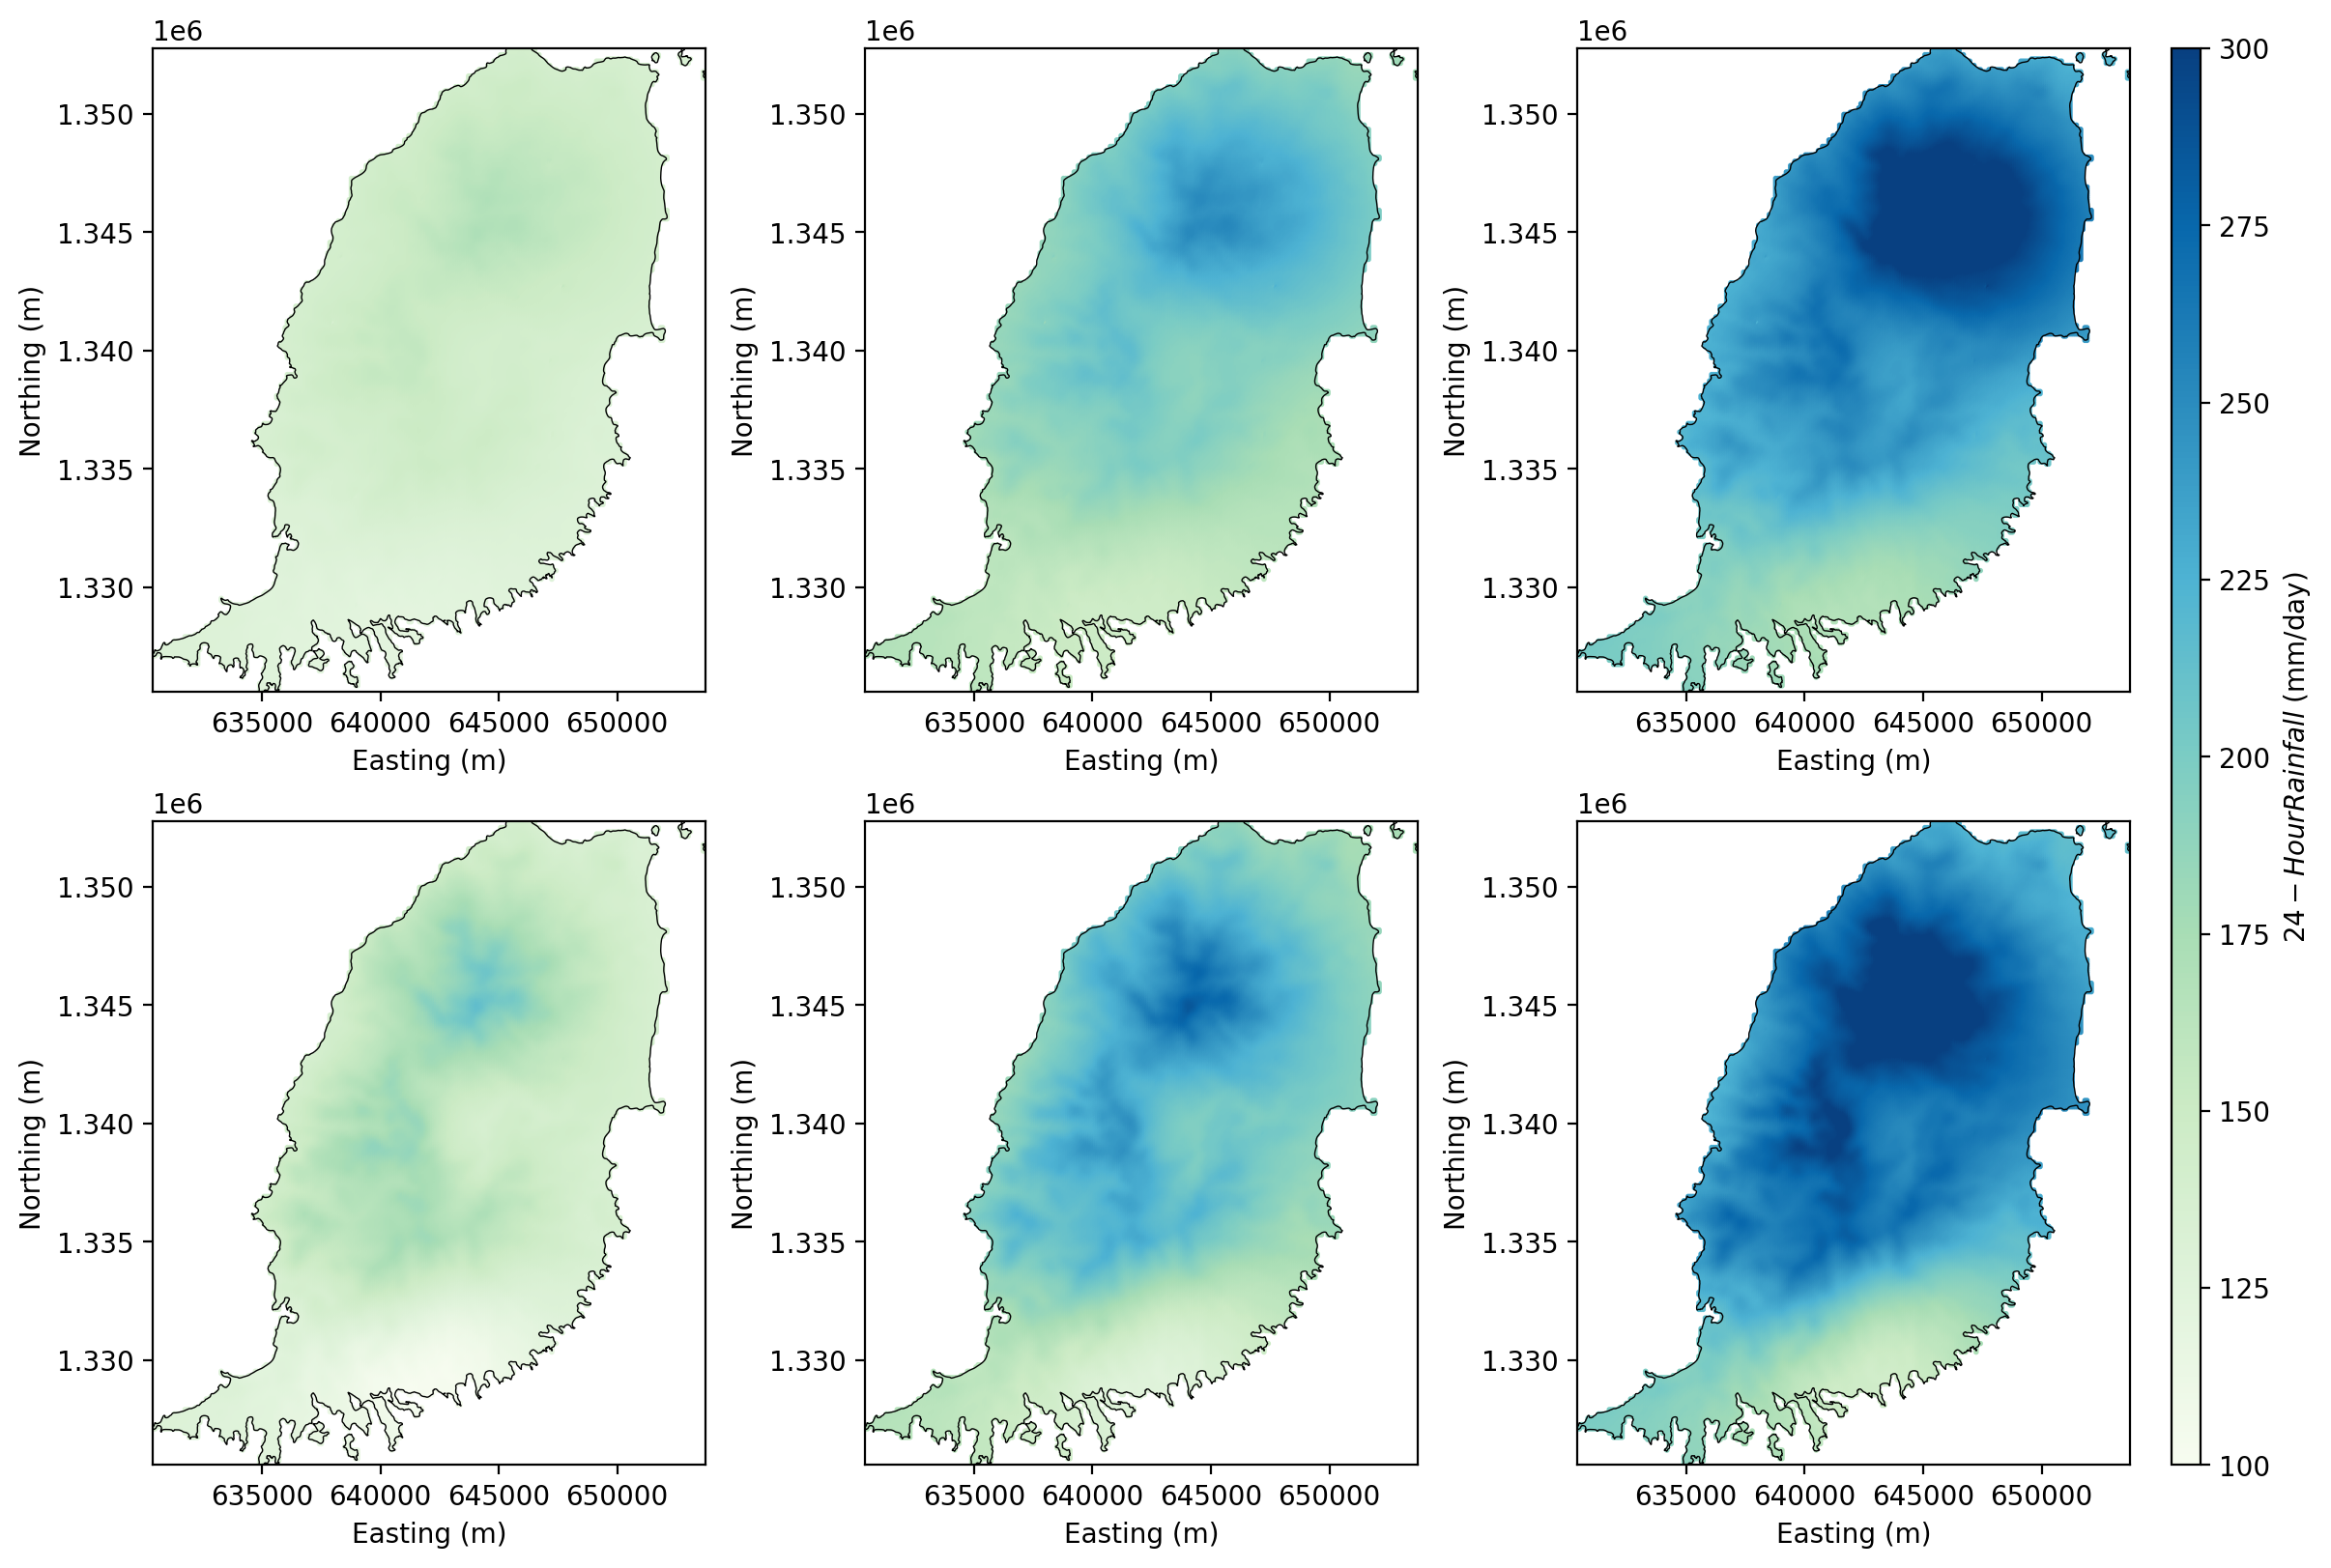

In [4]:
fig, ax = plt.subplots(2,3, figsize=(12, 8), dpi=200, constrained_layout=True)
sc = ax[0,0].scatter(gev_map['X_m'],gev_map['Y_m'], s=1, c=gev_map['oicckm2_10_mean'], cmap="GnBu", vmin = 100, vmax = 300)
ax[0,1].scatter(gev_map['X_m'],gev_map['Y_m'], s=1, c=gev_map['oicckm2_25_mean'], cmap="GnBu", vmin = 100, vmax = 300)
ax[0,2].scatter(gev_map['X_m'],gev_map['Y_m'], s=1, c=gev_map['oicckm2_50_mean'], cmap="GnBu", vmin = 100, vmax = 300)
ax[1,0].scatter(gev_map_errsta['X_m'],gev_map_errsta['Y_m'], s=1, c=gev_map_errsta['oicckm2_10_mean'], cmap="GnBu", vmin = 100, vmax = 300)
ax[1,1].scatter(gev_map_errsta['X_m'],gev_map_errsta['Y_m'], s=1, c=gev_map_errsta['oicckm2_25_mean'], cmap="GnBu", vmin = 100, vmax = 300)
ax[1,2].scatter(gev_map_errsta['X_m'],gev_map_errsta['Y_m'], s=1, c=gev_map_errsta['oicckm2_50_mean'], cmap="GnBu", vmin = 100, vmax = 300)
xmin = elev["X_m"].min()
xmax = elev["X_m"].max()
ymin = elev["Y_m"].min()
ymax = elev["Y_m"].max()
for a in ax.ravel():
    coast.plot(ax=a, color="none", edgecolor="black", linewidth=0.5)
    # a.scatter(stations['X_m'], stations['Y_m'], marker = "^", s = 20, color = "magenta", edgecolor = "black", linewidth = 0.5, alpha = 0.5)
    a.set_aspect("equal")
    a.set_xlim(xmin, xmax)
    a.set_ylim(ymin, ymax)
    a.set_xlabel("Easting (m)")
    a.set_ylabel("Northing (m)")
cbar = fig.colorbar(sc, ax=ax.ravel().tolist(), orientation="vertical", aspect = 50, fraction = 0.03, pad = 0.02)
cbar.set_label("$24-Hour Rainfall$ (mm/day)")
plt.show()

#### 4.2.1.2 Dtot

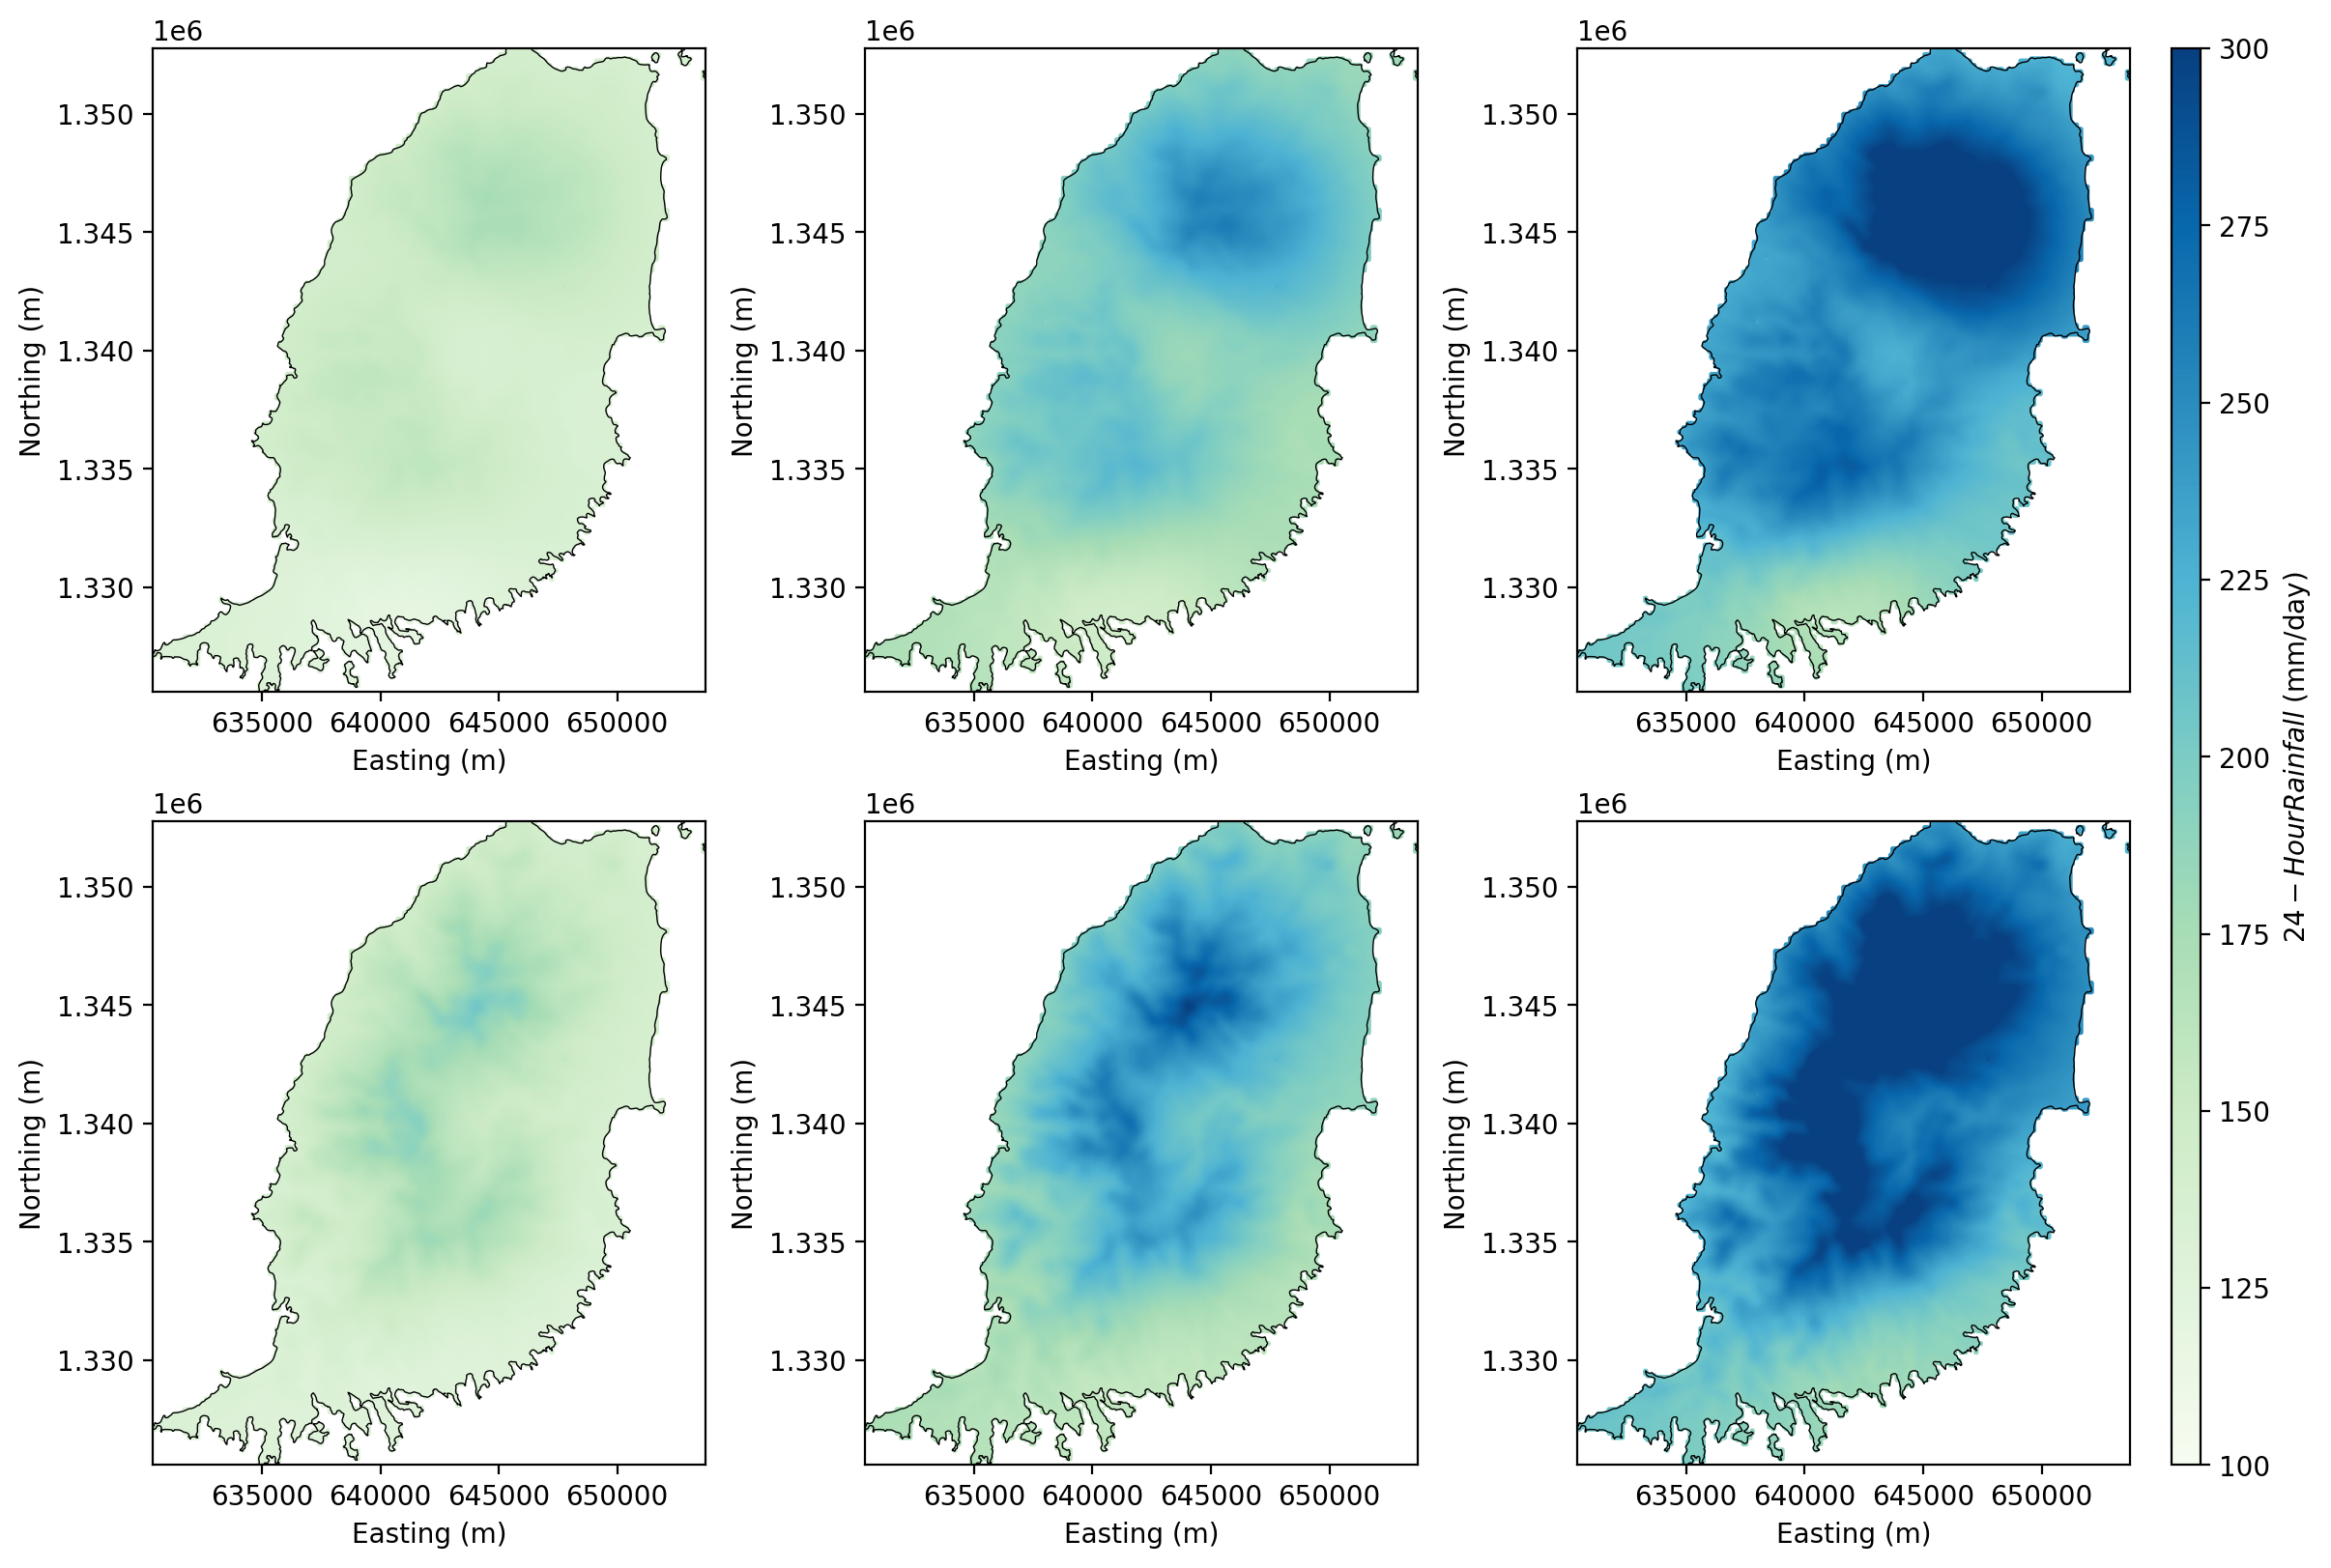

In [24]:
fig, ax = plt.subplots(2,3, figsize=(12, 8), dpi=200, constrained_layout=True)
sc = ax[0,0].scatter(gev_map_full['X_m'],gev_map_full['Y_m'], s=1, c=gev_map_full['oicckm2_10_mean'], cmap="GnBu", vmin = 100, vmax = 300)
ax[0,1].scatter(gev_map_full['X_m'],gev_map_full['Y_m'], s=1, c=gev_map_full['oicckm2_25_mean'], cmap="GnBu", vmin = 100, vmax = 300)
ax[0,2].scatter(gev_map_full['X_m'],gev_map_full['Y_m'], s=1, c=gev_map_full['oicckm2_50_mean'], cmap="GnBu", vmin = 100, vmax = 300)
ax[1,0].scatter(gev_map_full_errsta['X_m'],gev_map_full_errsta['Y_m'], s=1, c=gev_map_full_errsta['oicckm2_10_mean'], cmap="GnBu", vmin = 100, vmax = 300)
ax[1,1].scatter(gev_map_full_errsta['X_m'],gev_map_full_errsta['Y_m'], s=1, c=gev_map_full_errsta['oicckm2_25_mean'], cmap="GnBu", vmin = 100, vmax = 300)
ax[1,2].scatter(gev_map_full_errsta['X_m'],gev_map_full_errsta['Y_m'], s=1, c=gev_map_full_errsta['oicckm2_50_mean'], cmap="GnBu", vmin = 100, vmax = 300)
xmin = elev["X_m"].min()
xmax = elev["X_m"].max()
ymin = elev["Y_m"].min()
ymax = elev["Y_m"].max()
for a in ax.ravel():
    coast.plot(ax=a, color="none", edgecolor="black", linewidth=0.5)
    # a.scatter(stations['X_m'], stations['Y_m'], marker = "^", s = 20, color = "magenta", edgecolor = "black", linewidth = 0.5, alpha = 0.5)
    a.set_aspect("equal")
    a.set_xlim(xmin, xmax)
    a.set_ylim(ymin, ymax)
    a.set_xlabel("Easting (m)")
    a.set_ylabel("Northing (m)")
cbar = fig.colorbar(sc, ax=ax.ravel().tolist(), orientation="vertical", aspect = 50, fraction = 0.03, pad = 0.02)
cbar.set_label("$24-Hour Rainfall$ (mm/day)")
plt.show()

### 4.2.2 GPD: All stations vs. erroneous stations removed

#### 4.2.2.1 D80-D20

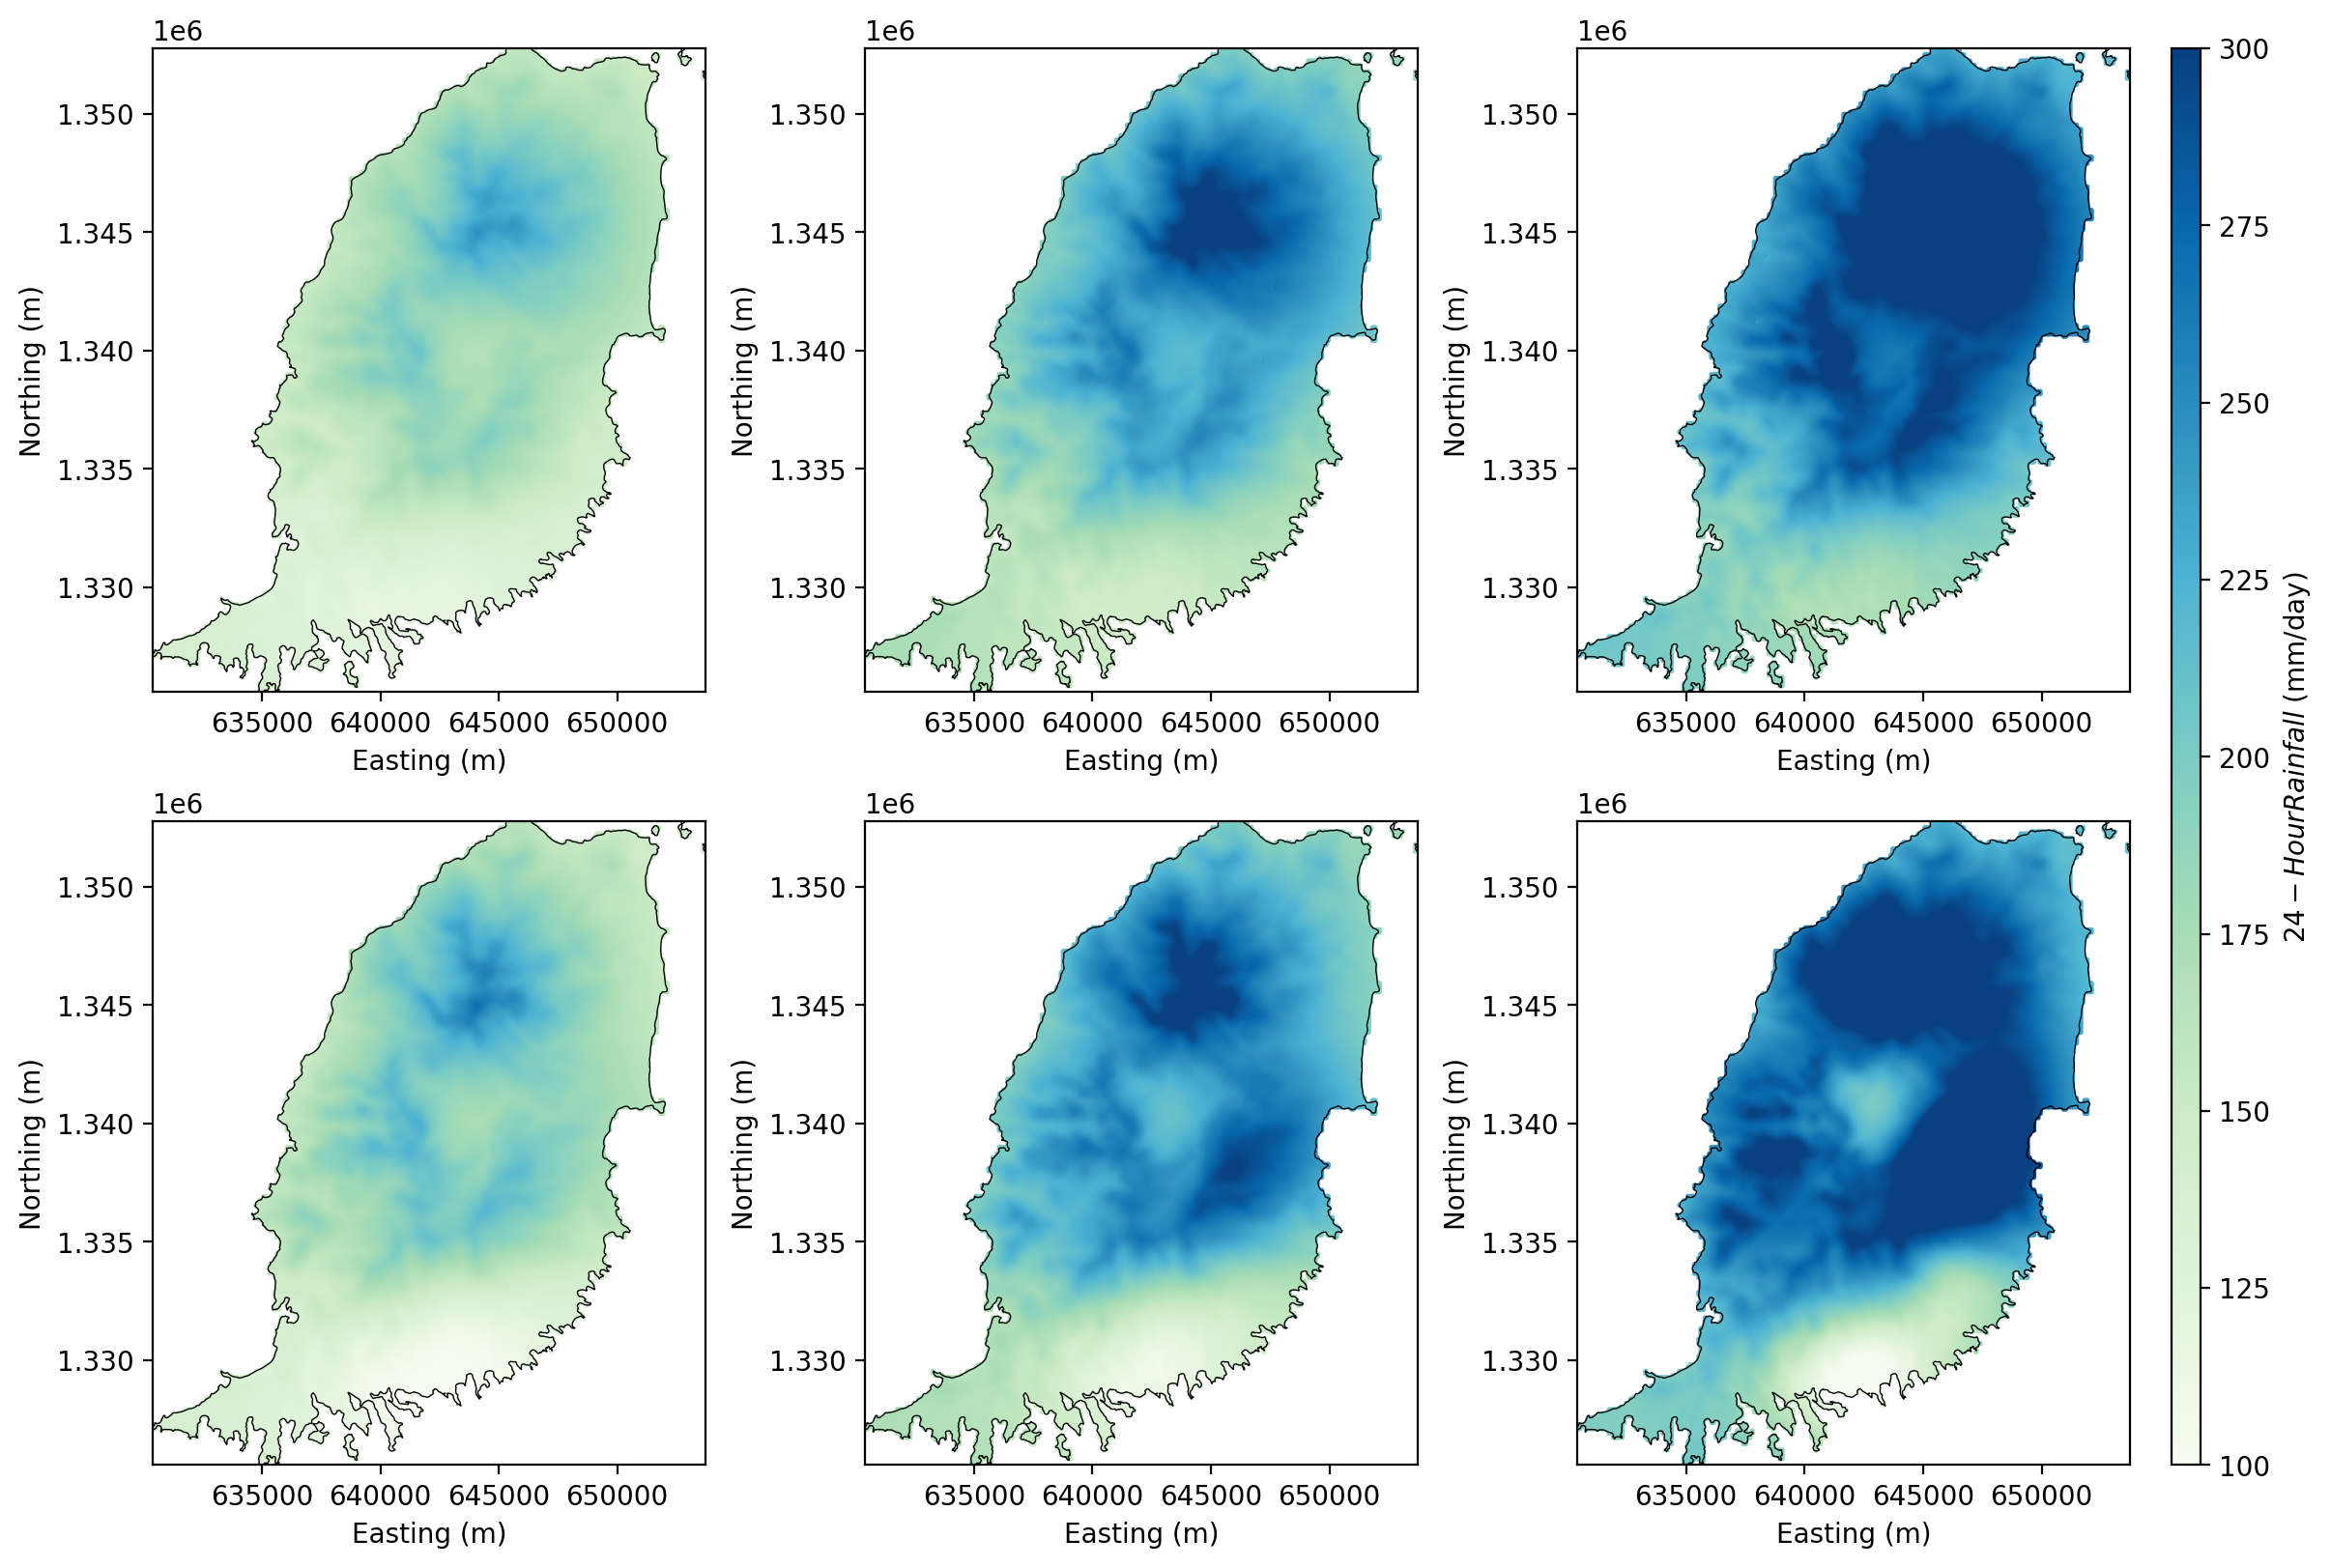

In [5]:
fig, ax = plt.subplots(2,3, figsize=(12, 8), dpi=200, constrained_layout=True)
sc = ax[0,0].scatter(gpd_map['X_m'],gpd_map['Y_m'], s=1, c=gpd_map['oicckm2_10_mean'], cmap="GnBu", vmin = 100, vmax = 300)
ax[0,1].scatter(gpd_map['X_m'],gpd_map['Y_m'], s=1, c=gpd_map['oicckm2_25_mean'], cmap="GnBu", vmin = 100, vmax = 300)
ax[0,2].scatter(gpd_map['X_m'],gpd_map['Y_m'], s=1, c=gpd_map['oicckm2_50_mean'], cmap="GnBu", vmin = 100, vmax = 300)
ax[1,0].scatter(gpd_map_errsta['X_m'],gpd_map_errsta['Y_m'], s=1, c=gpd_map_errsta['oicckm2_10_mean'], cmap="GnBu", vmin = 100, vmax = 300)
ax[1,1].scatter(gpd_map_errsta['X_m'],gpd_map_errsta['Y_m'], s=1, c=gpd_map_errsta['oicckm2_25_mean'], cmap="GnBu", vmin = 100, vmax = 300)
ax[1,2].scatter(gpd_map_errsta['X_m'],gpd_map_errsta['Y_m'], s=1, c=gpd_map_errsta['oicckm2_50_mean'], cmap="GnBu", vmin = 100, vmax = 300)
xmin = elev["X_m"].min()
xmax = elev["X_m"].max()
ymin = elev["Y_m"].min()
ymax = elev["Y_m"].max()
for a in ax.ravel():
    coast.plot(ax=a, color="none", edgecolor="black", linewidth=0.5)
    # a.scatter(stations['X_m'], stations['Y_m'], marker = "^", s = 20, color = "magenta", edgecolor = "black", linewidth = 0.5, alpha = 0.5)
    a.set_aspect("equal")
    a.set_xlim(xmin, xmax)
    a.set_ylim(ymin, ymax)
    a.set_xlabel("Easting (m)")
    a.set_ylabel("Northing (m)")
cbar = fig.colorbar(sc, ax=ax.ravel().tolist(), orientation="vertical", aspect = 50, fraction = 0.03, pad = 0.02)
cbar.set_label("$24-Hour Rainfall$ (mm/day)")
plt.show()

#### 4.2.2.2 Dtot

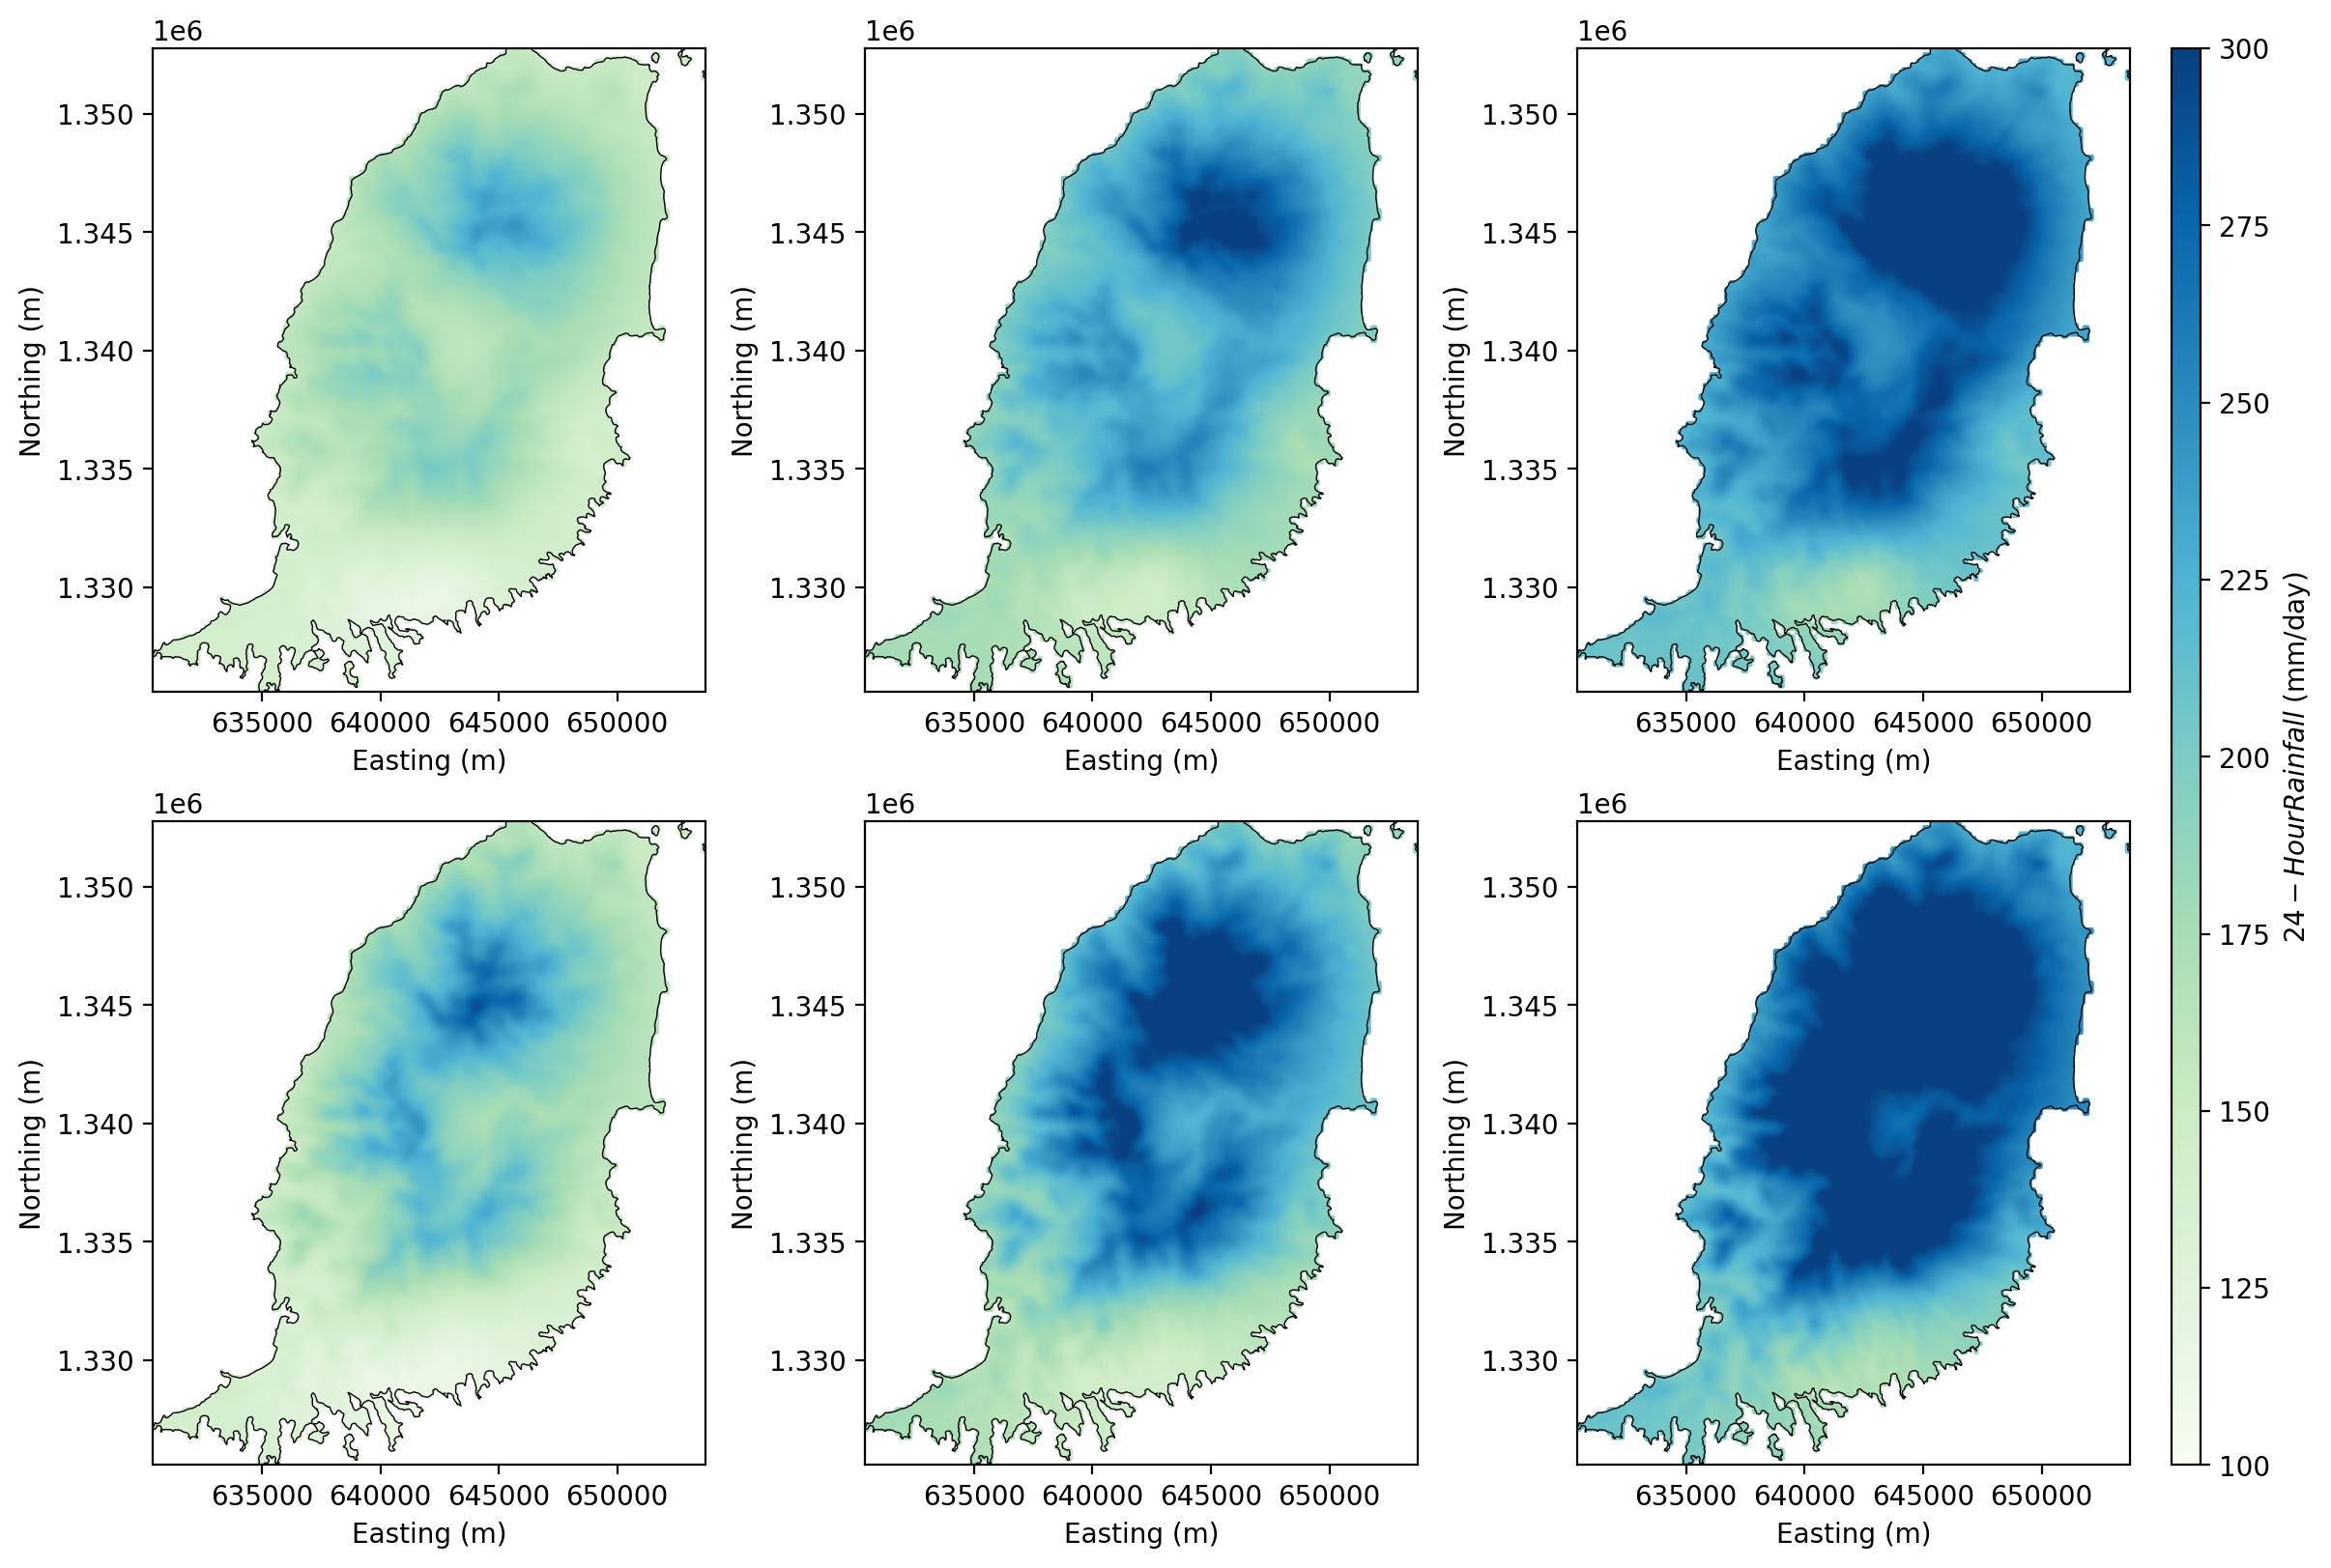

In [6]:
fig, ax = plt.subplots(2,3, figsize=(12, 8), dpi=200, constrained_layout=True)
sc = ax[0,0].scatter(gpd_map_full['X_m'],gpd_map_full['Y_m'], s=1, c=gpd_map_full['oicckm2_10_mean'], cmap="GnBu", vmin = 100, vmax = 300)
ax[0,1].scatter(gpd_map_full['X_m'],gpd_map_full['Y_m'], s=1, c=gpd_map_full['oicckm2_25_mean'], cmap="GnBu", vmin = 100, vmax = 300)
ax[0,2].scatter(gpd_map_full['X_m'],gpd_map_full['Y_m'], s=1, c=gpd_map_full['oicckm2_50_mean'], cmap="GnBu", vmin = 100, vmax = 300)
ax[1,0].scatter(gpd_map_full_errsta['X_m'],gpd_map_full_errsta['Y_m'], s=1, c=gpd_map_full_errsta['oicckm2_10_mean'], cmap="GnBu", vmin = 100, vmax = 300)
ax[1,1].scatter(gpd_map_full_errsta['X_m'],gpd_map_full_errsta['Y_m'], s=1, c=gpd_map_full_errsta['oicckm2_25_mean'], cmap="GnBu", vmin = 100, vmax = 300)
ax[1,2].scatter(gpd_map_full_errsta['X_m'],gpd_map_full_errsta['Y_m'], s=1, c=gpd_map_full_errsta['oicckm2_50_mean'], cmap="GnBu", vmin = 100, vmax = 300)
xmin = elev["X_m"].min()
xmax = elev["X_m"].max()
ymin = elev["Y_m"].min()
ymax = elev["Y_m"].max()
for a in ax.ravel():
    coast.plot(ax=a, color="none", edgecolor="black", linewidth=0.5)
    # a.scatter(stations['X_m'], stations['Y_m'], marker = "^", s = 20, color = "magenta", edgecolor = "black", linewidth = 0.5, alpha = 0.5)
    a.set_aspect("equal")
    a.set_xlim(xmin, xmax)
    a.set_ylim(ymin, ymax)
    a.set_xlabel("Easting (m)")
    a.set_ylabel("Northing (m)")
cbar = fig.colorbar(sc, ax=ax.ravel().tolist(), orientation="vertical", aspect = 50, fraction = 0.03, pad = 0.02)
cbar.set_label("$24-Hour Rainfall$ (mm/day)")
plt.show()

### 4.2.3 GEV vs. GPD: mean

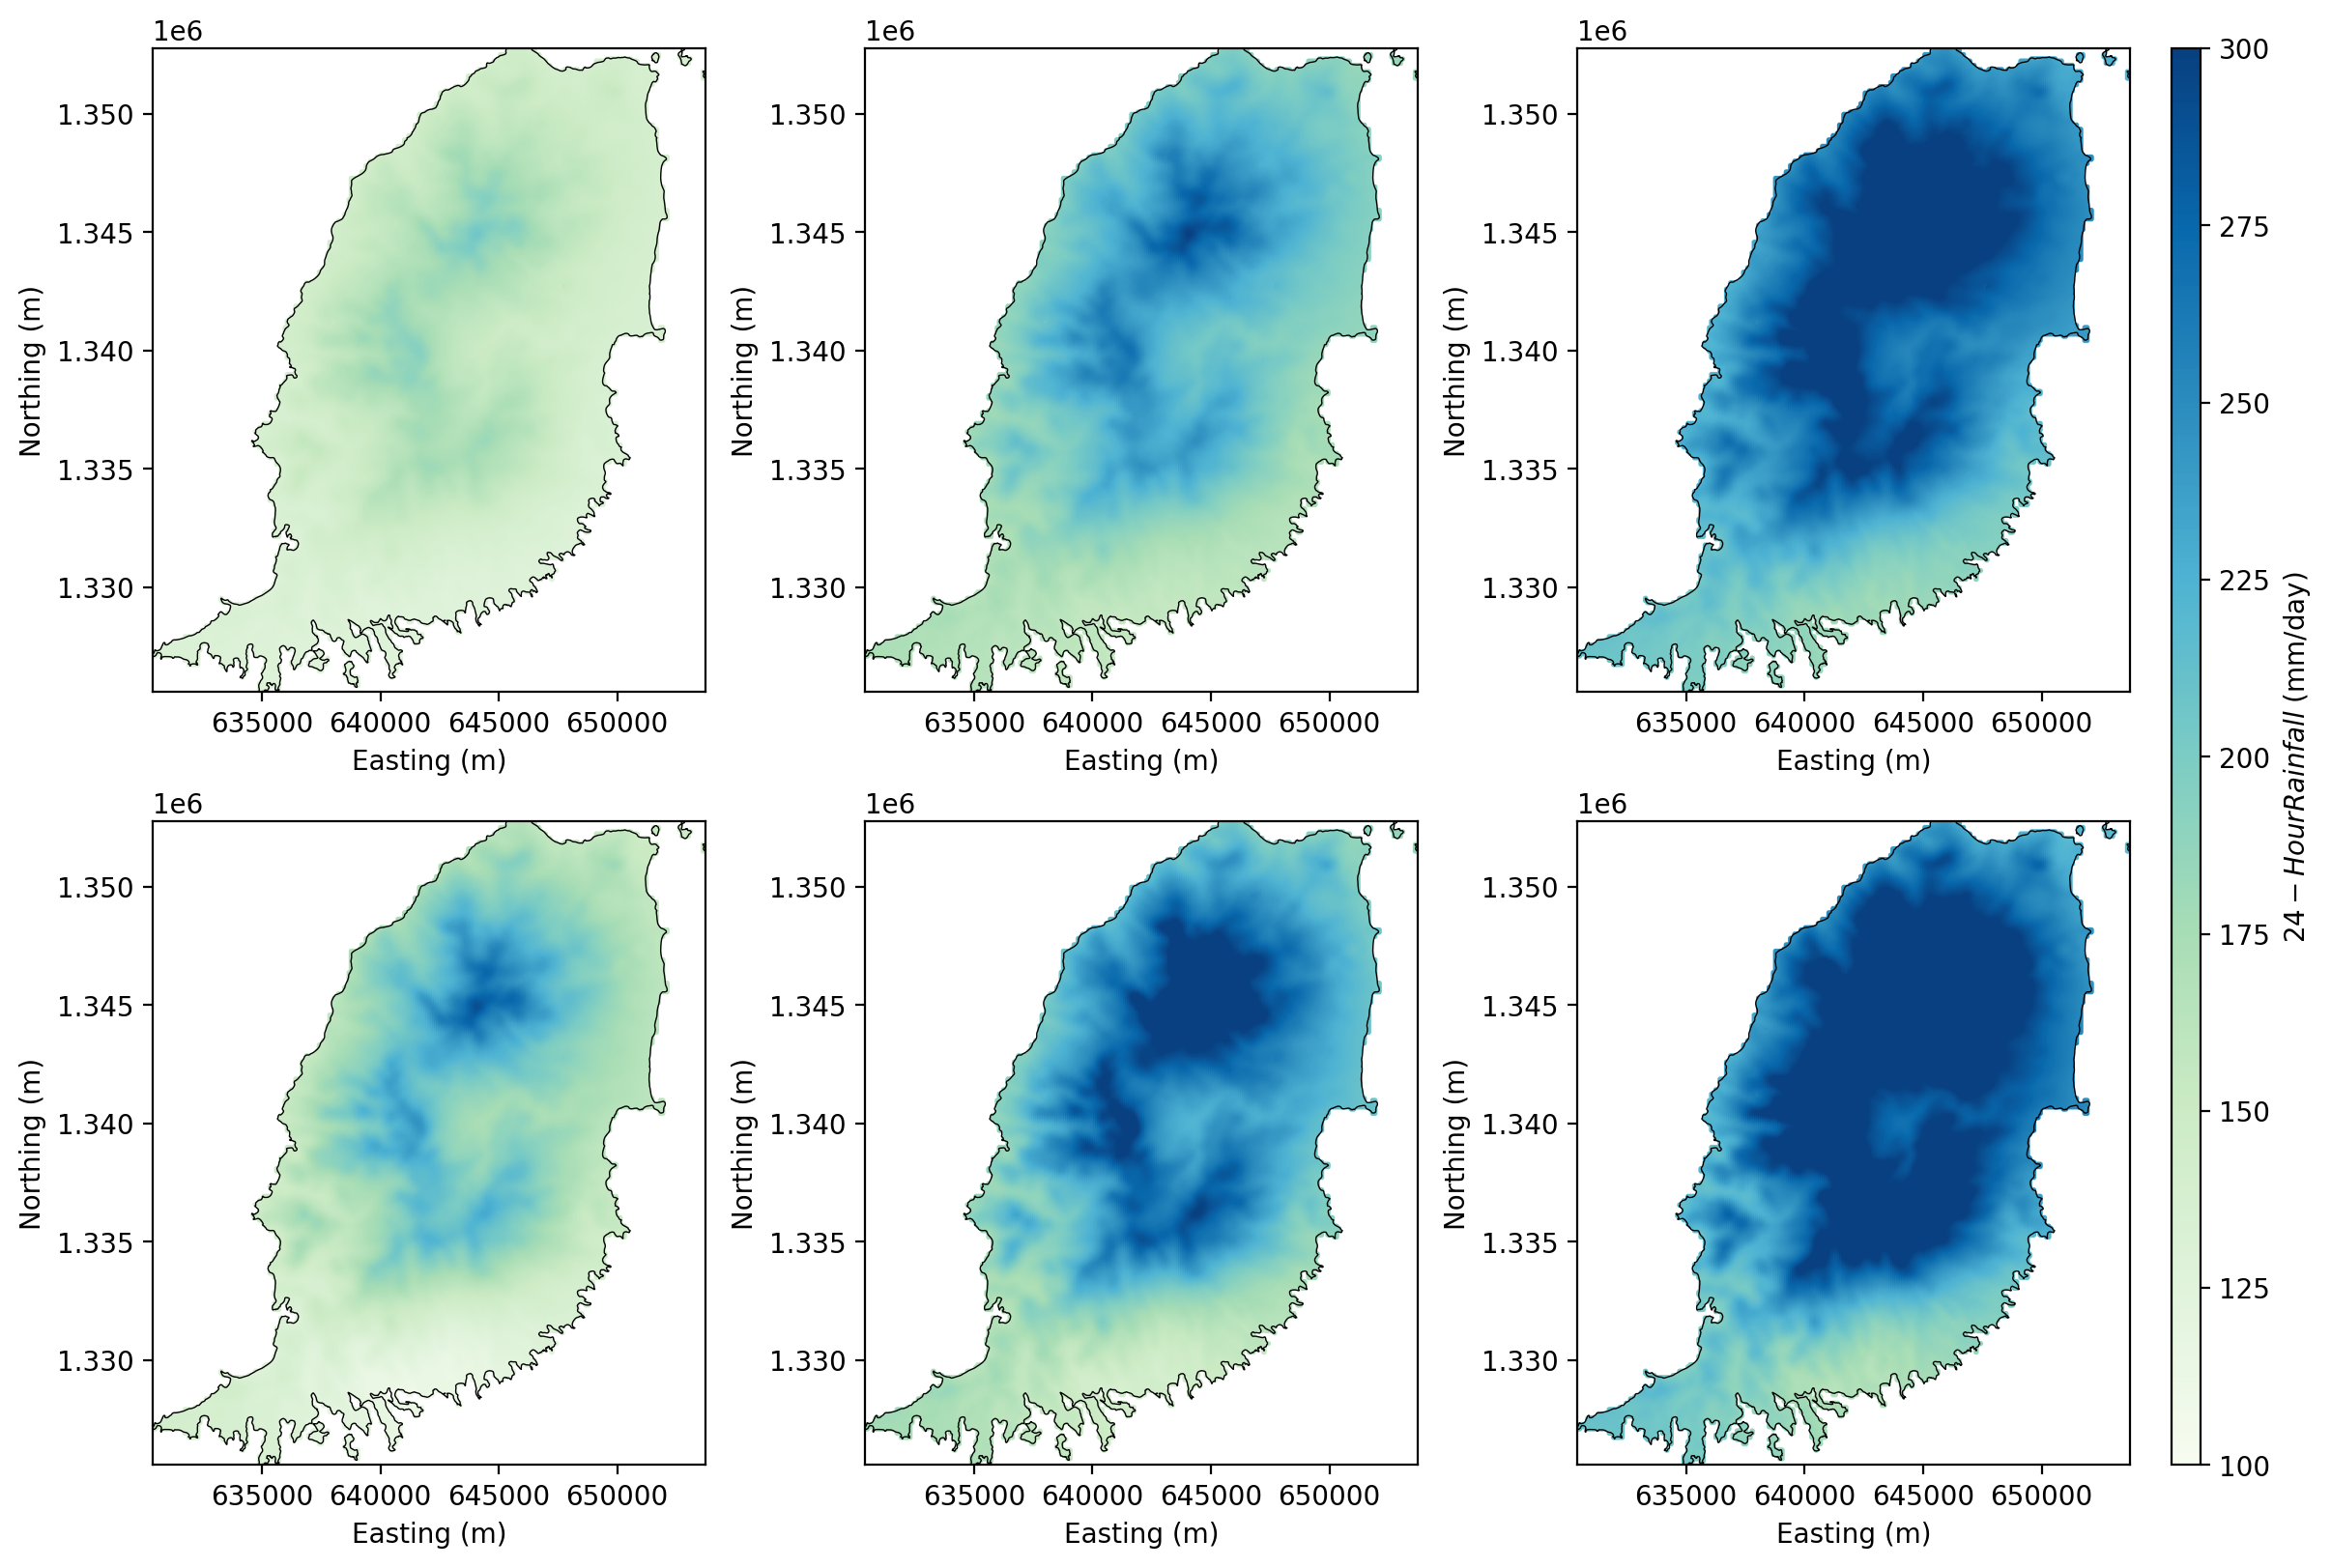

In [26]:
fig, ax = plt.subplots(2,3, figsize=(12, 8), dpi=200, constrained_layout=True)
sc = ax[0,0].scatter(gev_map_full_errsta['X_m'],gev_map_full_errsta['Y_m'], s=1, c=gev_map_full_errsta['oicckm2_10_mean'], cmap="GnBu", vmin = 100, vmax = 300)
ax[0,1].scatter(gev_map_full_errsta['X_m'],gev_map_full_errsta['Y_m'], s=1, c=gev_map_full_errsta['oicckm2_25_mean'], cmap="GnBu", vmin = 100, vmax = 300)
ax[0,2].scatter(gev_map_full_errsta['X_m'],gev_map_full_errsta['Y_m'], s=1, c=gev_map_full_errsta['oicckm2_50_mean'], cmap="GnBu", vmin = 100, vmax = 300)
ax[1,0].scatter(gpd_map_full_errsta['X_m'],gpd_map_full_errsta['Y_m'], s=1, c=gpd_map_full_errsta['oicckm2_10_mean'], cmap="GnBu", vmin = 100, vmax = 300)
ax[1,1].scatter(gpd_map_full_errsta['X_m'],gpd_map_full_errsta['Y_m'], s=1, c=gpd_map_full_errsta['oicckm2_25_mean'], cmap="GnBu", vmin = 100, vmax = 300)
ax[1,2].scatter(gpd_map_full_errsta['X_m'],gpd_map_full_errsta['Y_m'], s=1, c=gpd_map_full_errsta['oicckm2_50_mean'], cmap="GnBu", vmin = 100, vmax = 300)
xmin = elev["X_m"].min()
xmax = elev["X_m"].max()
ymin = elev["Y_m"].min()
ymax = elev["Y_m"].max()
for a in ax.ravel():
    coast.plot(ax=a, color="none", edgecolor="black", linewidth=0.5)
    # a.scatter(stations['X_m'], stations['Y_m'], marker = "^", s = 20, color = "magenta", edgecolor = "black", linewidth = 0.5, alpha = 0.5)
    a.set_aspect("equal")
    a.set_xlim(xmin, xmax)
    a.set_ylim(ymin, ymax)
    a.set_xlabel("Easting (m)")
    a.set_ylabel("Northing (m)")
cbar = fig.colorbar(sc, ax=ax.ravel().tolist(), orientation="vertical", aspect = 50, fraction = 0.03, pad = 0.02)
cbar.set_label("$24-Hour Rainfall$ (mm/day)")
plt.show()

### 4.2.4 GEV vs. GPD: standard deviation

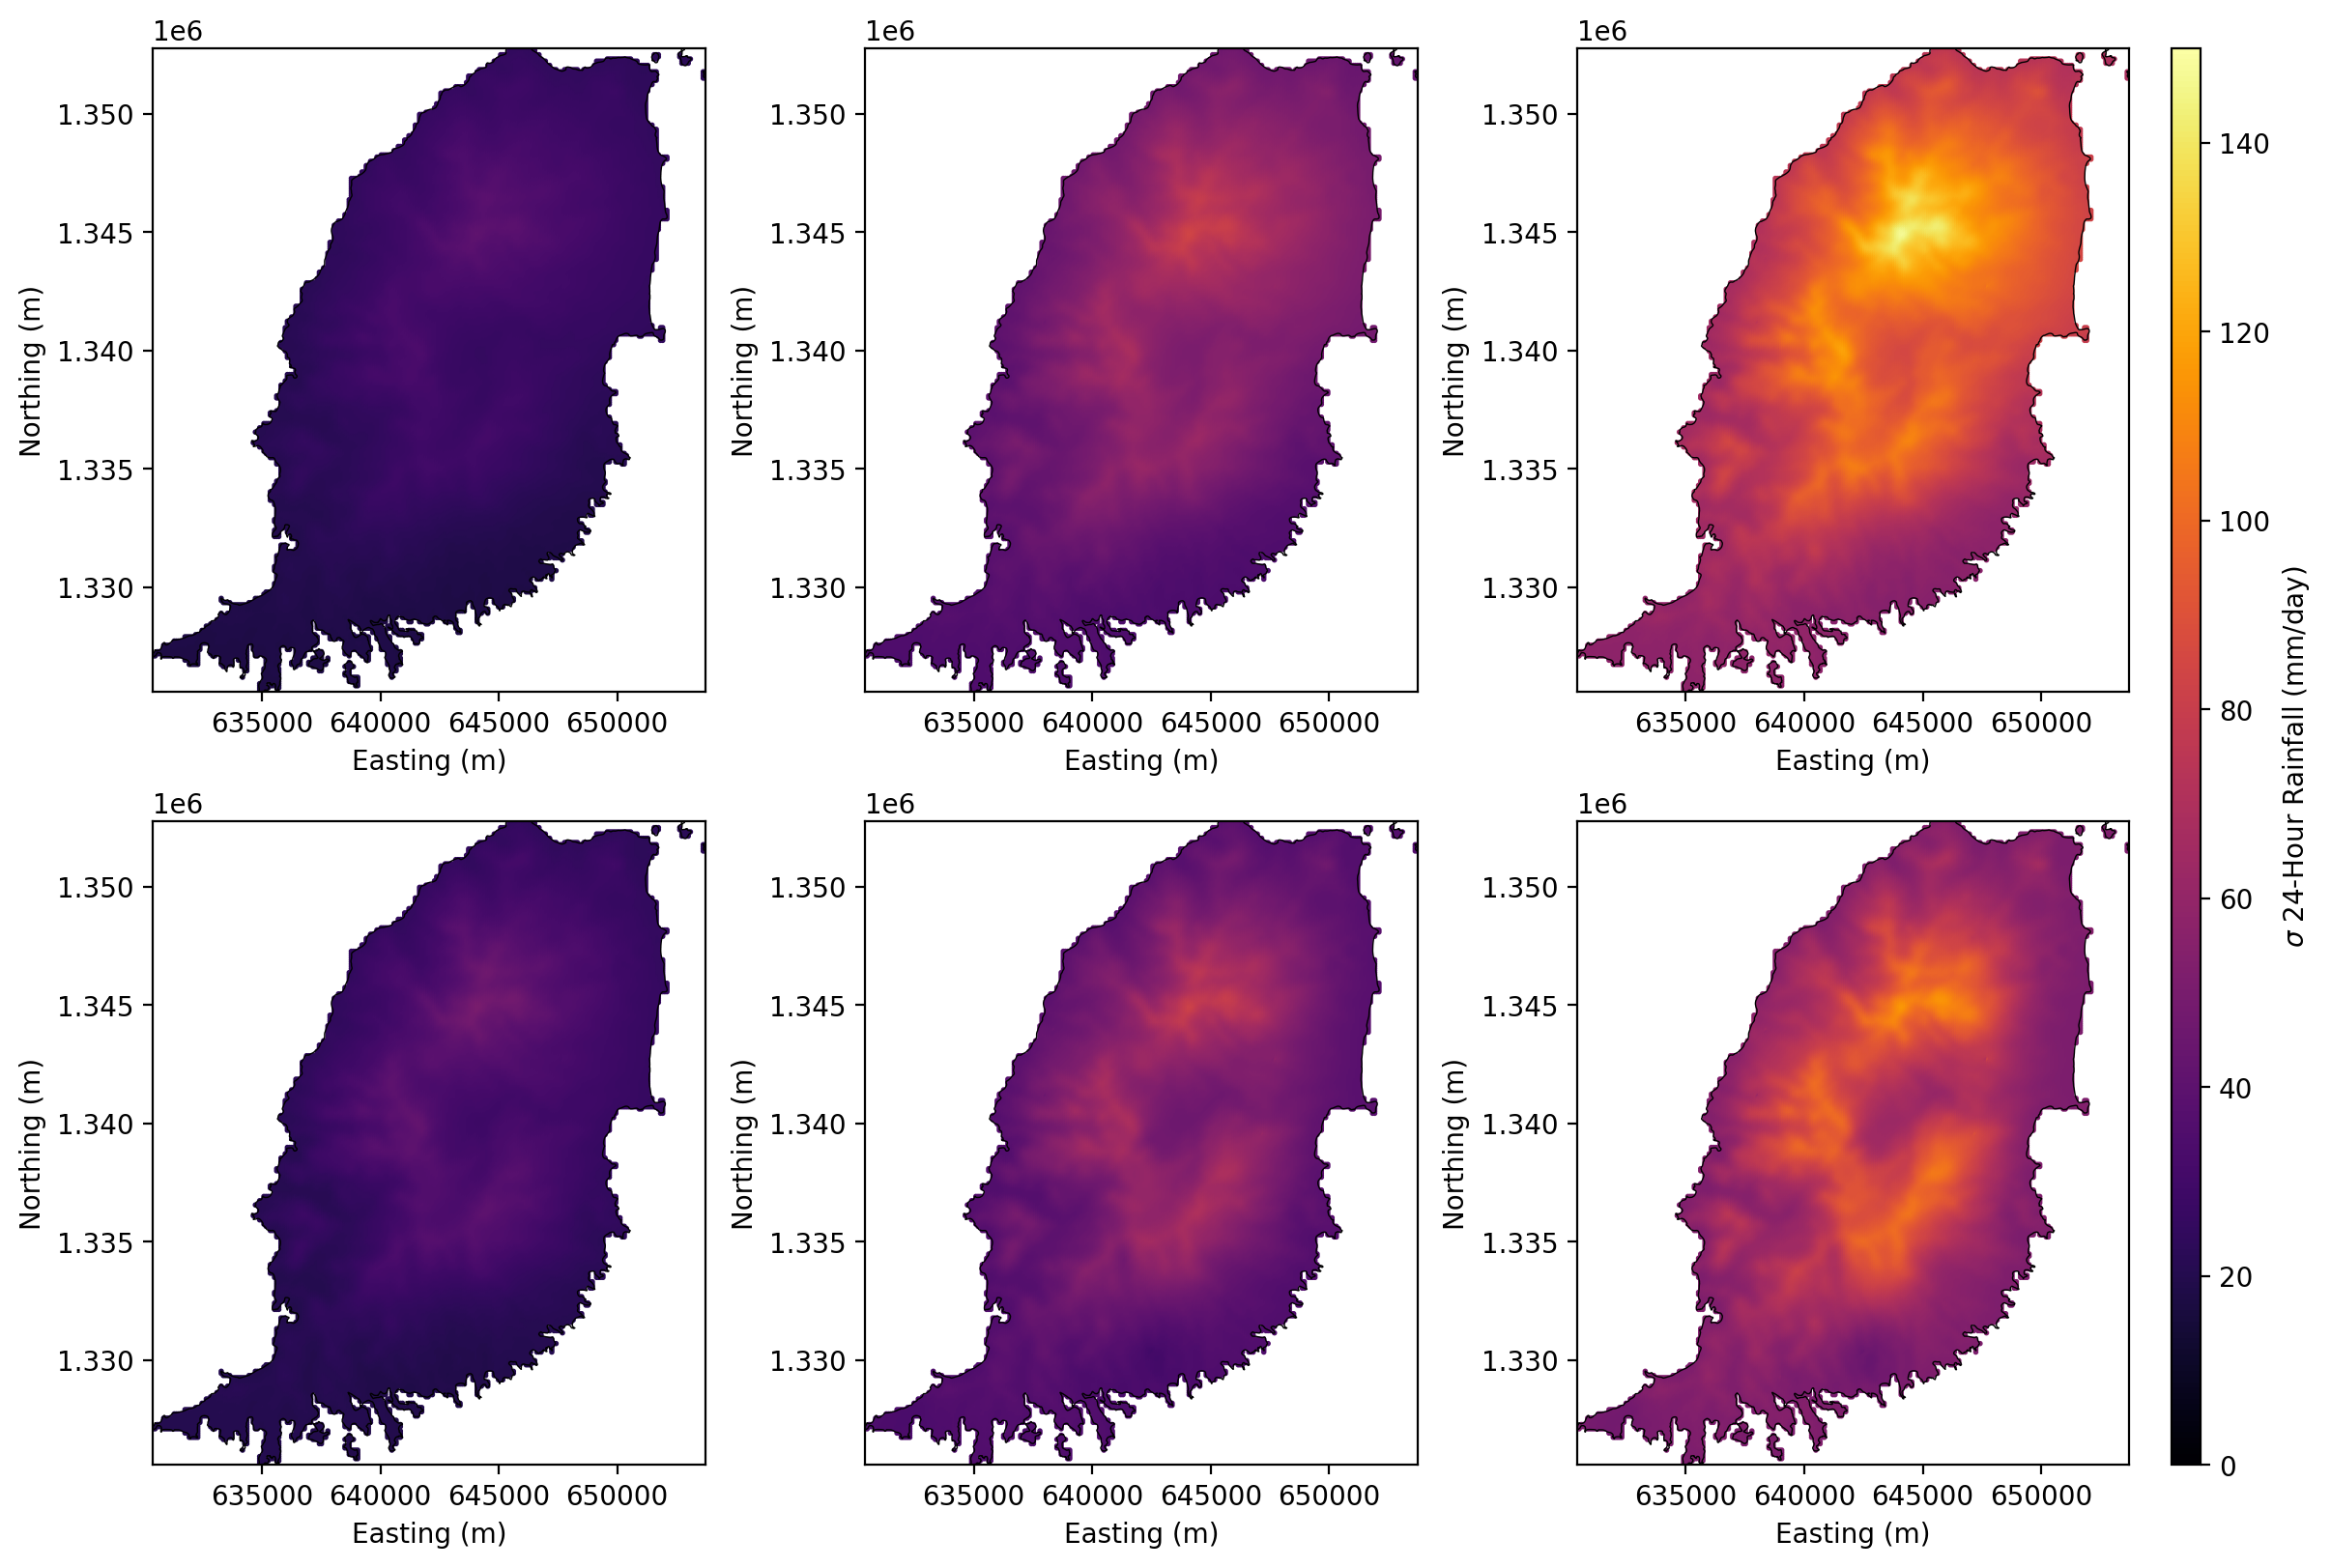

In [7]:
fig, ax = plt.subplots(2,3, figsize=(12, 8), dpi=200, constrained_layout=True)
sc = ax[0,0].scatter(gev_map_full_errsta['X_m'],gev_map_full_errsta['Y_m'], s=1, c=gev_map_full_errsta['oicckm2_10_std'], cmap="inferno", vmin = 0, vmax = 150)
ax[0,1].scatter(gev_map_full_errsta['X_m'],gev_map_full_errsta['Y_m'], s=1, c=gev_map_full_errsta['oicckm2_25_std'], cmap="inferno", vmin = 0, vmax = 150)
ax[0,2].scatter(gev_map_full_errsta['X_m'],gev_map_full_errsta['Y_m'], s=1, c=gev_map_full_errsta['oicckm2_50_std'], cmap="inferno", vmin = 0, vmax = 150)
ax[1,0].scatter(gpd_map_full_errsta['X_m'],gpd_map_full_errsta['Y_m'], s=1, c=gpd_map_full_errsta['oicckm2_10_std'], cmap="inferno", vmin = 0, vmax = 150)
ax[1,1].scatter(gpd_map_full_errsta['X_m'],gpd_map_full_errsta['Y_m'], s=1, c=gpd_map_full_errsta['oicckm2_25_std'], cmap="inferno", vmin = 0, vmax = 150)
ax[1,2].scatter(gpd_map_full_errsta['X_m'],gpd_map_full_errsta['Y_m'], s=1, c=gpd_map_full_errsta['oicckm2_50_std'], cmap="inferno", vmin = 0, vmax = 150)
xmin = elev["X_m"].min()
xmax = elev["X_m"].max()
ymin = elev["Y_m"].min()
ymax = elev["Y_m"].max()
for a in ax.ravel():
    coast.plot(ax=a, color="none", edgecolor="black", linewidth=0.5)
    # a.scatter(stations['X_m'], stations['Y_m'], marker = "^", s = 20, color = "magenta", edgecolor = "black", linewidth = 0.5, alpha = 0.5)
    a.set_aspect("equal")
    a.set_xlim(xmin, xmax)
    a.set_ylim(ymin, ymax)
    a.set_xlabel("Easting (m)")
    a.set_ylabel("Northing (m)")
cbar = fig.colorbar(sc, ax=ax.ravel().tolist(), orientation="vertical", aspect = 50, fraction = 0.03, pad = 0.02)
cbar.set_label(r"$\sigma$ 24-Hour Rainfall (mm/day)")
plt.savefig('sig.png', dpi = 200)
plt.show()

# 5.0 Folium map creation

## 5.1 Module imports

In [8]:
from pathlib import Path
import re
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, to_hex
from pyproj import Transformer

import folium
from folium.raster_layers import ImageOverlay
from branca.element import MacroElement, Template

## 5.2 Helper functions

In [11]:
def detect_return_level_columns(df, method_filter="oicckm2"):
    """
    Detect return-level columns for a selected interpolation/model method.

    Expected column names include:
        ock_10_mean
        oicckm1_10_mean
        oicckm2_10_mean
        oicckm2_50_std

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataframe.
    method_filter : str or None
        Method prefix to keep, e.g. "oicckm2".
        If None, all matching methods are kept.

    Returns
    -------
    list of dict
        Each dictionary contains:
        - method: column prefix, e.g. "oicckm2"
        - return_period: string label, e.g. "10"
        - return_period_value: numeric return period
        - stat: "mean" or "std"
        - column: source column name
    """
    out = []

    for col in df.columns:
        match = re.match(r"^(.+)_(\d+(?:\.\d+)?)_(mean|std)$", col)

        if match:
            method = match.group(1)
            rp_value = float(match.group(2))
            stat = match.group(3)

            if method_filter is not None and method != method_filter:
                continue

            out.append({
                "method": method,
                "return_period": f"{rp_value:g}",
                "return_period_value": rp_value,
                "stat": stat,
                "column": col,
            })

    return sorted(out, key=lambda d: (d["return_period_value"], d["stat"]))


def infer_spacing(vals):
    """
    Infer the median spacing from a 1D coordinate array.
    """
    vals = np.sort(np.unique(np.asarray(vals, dtype=float)))
    diffs = np.diff(vals)
    diffs = diffs[diffs > 0]

    if len(diffs) == 0:
        raise ValueError("Could not infer grid spacing.")

    return float(np.median(diffs))


def prepare_grid_dataframe(df, grid_res_m=None, grid_stride=1):
    """
    Optionally round and thin a regular X_m/Y_m grid before web export.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataframe containing X_m and Y_m.
    grid_res_m : float or None
        If given, X_m and Y_m are rounded to this spacing.
    grid_stride : int
        Keep every nth X and Y grid coordinate. Use 1 to keep the full grid.

    Returns
    -------
    pandas.DataFrame
        Prepared dataframe.
    """
    df = df.copy()

    if grid_res_m is not None:
        df["X_m"] = np.round(df["X_m"] / grid_res_m) * grid_res_m
        df["Y_m"] = np.round(df["Y_m"] / grid_res_m) * grid_res_m

    if grid_stride is not None and grid_stride > 1:
        x = np.sort(df["X_m"].unique())
        y = np.sort(df["Y_m"].unique())

        x_keep = list(x[::grid_stride])
        y_keep = list(y[::grid_stride])

        # Keep outer boundaries so the map extent is not unintentionally cropped.
        if x[-1] not in x_keep:
            x_keep.append(x[-1])
        if y[-1] not in y_keep:
            y_keep.append(y[-1])

        df = df[df["X_m"].isin(x_keep) & df["Y_m"].isin(y_keep)].copy()

    return df


def print_grid_diagnostics(df, name):
    """
    Print basic checks for the regular grid geometry.
    """
    x = np.sort(df["X_m"].unique())
    y = np.sort(df["Y_m"].unique())

    dx = infer_spacing(x)
    dy = infer_spacing(y)

    nx = len(x)
    ny = len(y)
    n_expected = nx * ny
    n_actual = len(df)

    print("\n" + str(name))
    print(f"  rows        : {n_actual:,}")
    print(f"  nx, ny      : {nx:,}, {ny:,}")
    print(f"  nx * ny     : {n_expected:,}")
    print(f"  coverage    : {n_actual / n_expected:.3f}")
    print(f"  dx, dy      : {dx:.3f}, {dy:.3f}")
    print(f"  X range     : {df['X_m'].min():.3f} to {df['X_m'].max():.3f}")
    print(f"  Y range     : {df['Y_m'].min():.3f} to {df['Y_m'].max():.3f}")


def cmap_gradient_css(cmap_name, n=9):
    """
    Convert a Matplotlib colormap into a CSS vertical gradient.
    """
    cmap = plt.get_cmap(cmap_name)

    stops = []
    for i in range(n):
        f = i / (n - 1)
        stops.append(f"{to_hex(cmap(f))} {100 * f:.0f}%")

    return "linear-gradient(to top, " + ", ".join(stops) + ")"


def cmap_colors(cmap_name, n=11):
    """
    Convert a Matplotlib colormap to a small list of hex colours for JavaScript.
    """
    cmap = plt.get_cmap(cmap_name)
    return [to_hex(cmap(i / (n - 1))) for i in range(n)]


def build_rainfall_polygon_geojson(
    csv_layers,
    src_crs,
    method_filter="oicckm2",
    return_periods_to_keep=None,
    stats_to_keep=None,
    grid_res_m=None,
    grid_stride=1,
    cell_half_width_factor=0.5,
    coord_decimals=5,
    value_decimals=0,
    drop_cells_with_all_missing=True,
    print_diagnostics=True,
):
    """
    Build a compact true polygon-cell GeoJSON rainfall layer.

    Each X_m/Y_m grid point is treated as the centre of a grid cell.
    Cell corners are constructed in the projected CRS and transformed to
    lon/lat corner-by-corner. This avoids the rectangular ImageOverlay
    stretching problem.

    To reduce HTML size, rainfall values are stored as a compact array in
    feature.properties["v"], rather than repeating long property names in
    every grid cell.

    Parameters
    ----------
    csv_layers : dict
        Mapping of (distribution, dataset_name) to CSV path.
    src_crs : str
        CRS of X_m/Y_m, e.g. "EPSG:32620".
    method_filter : str or None
        Method prefix to keep, e.g. "oicckm2".
    return_periods_to_keep : set or None
        Return-period labels to keep, e.g. {"10", "25", "50"}.
        If None, all detected return periods are kept.
    stats_to_keep : set or None
        Statistics to keep, e.g. {"mean", "std"}.
    grid_res_m : float or None
        Optional rounding spacing for X_m/Y_m.
    grid_stride : int
        Keep every nth X and Y coordinate.
    cell_half_width_factor : float
        Usually 0.5 when X_m/Y_m are cell centres.
    coord_decimals : int
        Number of decimals for lon/lat coordinates in GeoJSON.
        5 decimals is approximately metre-level precision.
    value_decimals : int
        Number of decimals stored for rainfall values.
    drop_cells_with_all_missing : bool
        If True, cells with no selected rainfall values are omitted.
    print_diagnostics : bool
        Print grid and detected-column diagnostics.

    Returns
    -------
    geojson : dict
        FeatureCollection with true lon/lat cell polygons.
    layer_specs : list of dict
        Metadata used by the JavaScript dropdown.
    bounds : list
        Folium bounds in the form [[south, west], [north, east]].
    """
    transformer = Transformer.from_crs(src_crs, "EPSG:4326", always_xy=True)

    cell_values = {}
    layer_specs = []

    for (distribution, dataset_name), csv_path in csv_layers.items():
        csv_path = Path(csv_path)
        df = pd.read_csv(csv_path)

        missing = {"X_m", "Y_m"}.difference(df.columns)
        if missing:
            raise ValueError(f"{csv_path} is missing required columns: {missing}")

        df = prepare_grid_dataframe(
            df,
            grid_res_m=grid_res_m,
            grid_stride=grid_stride,
        )

        dup_mask = df.duplicated(subset=["X_m", "Y_m"], keep=False)
        if dup_mask.any():
            raise ValueError(
                f"{csv_path} contains {int(dup_mask.sum())} duplicate X_m/Y_m rows "
                "after grid preparation. Try GRID_RES_M=None or check the input grid."
            )

        if print_diagnostics:
            print_grid_diagnostics(df, csv_path.name)

        value_cols = detect_return_level_columns(df, method_filter=method_filter)

        selected_items = []
        for item in value_cols:
            rp = item["return_period"]
            stat = item["stat"]

            if return_periods_to_keep is not None and rp not in return_periods_to_keep:
                continue

            if stats_to_keep is not None and stat not in stats_to_keep:
                continue

            selected_items.append(item)

        if print_diagnostics:
            print("  detected selected columns:")
            for item in selected_items:
                print(f"    {item['column']}")

        for item in selected_items:
            method = item["method"]
            rp = item["return_period"]
            stat = item["stat"]
            value_col = item["column"]

            layer_index = len(layer_specs)

            layer_specs.append({
                "index": layer_index,
                "distribution": distribution,
                "dataset": dataset_name,
                "method": method,
                "return_period": rp,
                "stat": stat,
                "column": value_col,
            })

            for x, y, value in df[["X_m", "Y_m", value_col]].itertuples(index=False, name=None):
                key = (float(x), float(y))

                if key not in cell_values:
                    cell_values[key] = {}

                if pd.notna(value):
                    if value_decimals == 0:
                        cell_values[key][layer_index] = int(round(float(value)))
                    else:
                        cell_values[key][layer_index] = round(float(value), value_decimals)

    if not cell_values:
        raise ValueError("No cells were created. Check CSV_LAYERS and selected columns.")

    if not layer_specs:
        raise ValueError(
            "No rainfall layers were selected. Check METHOD_FILTER, "
            "RETURN_PERIODS_TO_KEEP, and STATS_TO_KEEP."
        )

    x_all = np.array([xy[0] for xy in cell_values.keys()], dtype=float)
    y_all = np.array([xy[1] for xy in cell_values.keys()], dtype=float)

    dx = infer_spacing(x_all)
    dy = infer_spacing(y_all)

    n_layers = len(layer_specs)

    features = []

    west = np.inf
    east = -np.inf
    south = np.inf
    north = -np.inf

    for x, y in cell_values.keys():
        values_by_index = cell_values[(x, y)]

        values = [
            values_by_index.get(i, None)
            for i in range(n_layers)
        ]

        if drop_cells_with_all_missing and all(v is None for v in values):
            continue

        x0 = x - cell_half_width_factor * dx
        x1 = x + cell_half_width_factor * dx
        y0 = y - cell_half_width_factor * dy
        y1 = y + cell_half_width_factor * dy

        xs = [x0, x1, x1, x0, x0]
        ys = [y0, y0, y1, y1, y0]

        lons, lats = transformer.transform(xs, ys)

        coords = []
        for lon, lat in zip(lons, lats):
            lon = round(float(lon), coord_decimals)
            lat = round(float(lat), coord_decimals)

            coords.append([lon, lat])

            west = min(west, lon)
            east = max(east, lon)
            south = min(south, lat)
            north = max(north, lat)

        features.append({
            "type": "Feature",
            "properties": {
                "v": values,
            },
            "geometry": {
                "type": "Polygon",
                "coordinates": [coords],
            },
        })

    geojson = {
        "type": "FeatureCollection",
        "features": features,
    }

    bounds = [[south, west], [north, east]]

    return geojson, layer_specs, bounds

## 5.3 Folium control class

In [9]:
class RainfallPolygonControl(MacroElement):
    """
    Custom Leaflet/Folium control for displaying true lon/lat polygon cells.

    The map contains one GeoJSON polygon layer. Dropdown changes update the
    fill colour according to the selected rainfall property.
    """

    def __init__(self, geojson, layer_specs, stat_config, default_opacity=0.85):
        super().__init__()
        self._name = "RainfallPolygonControl"

        self.geojson_json = json.dumps(geojson, separators=(",", ":"))
        self.layer_specs_json = json.dumps(layer_specs, separators=(",", ":"))
        self.stat_config_json = json.dumps(stat_config, separators=(",", ":"))
        self.default_opacity = default_opacity

        self._template = Template("""
        {% macro html(this, kwargs) %}
        <div id="rainfall-control">
            <div class="rain-title">Rainfall extreme map</div>

            <label>Distribution</label>
            <select id="rain-dist"></select>

            <label>Dataset</label>
            <select id="rain-dataset"></select>

            <label>Statistic</label>
            <select id="rain-stat"></select>

            <label>Return period</label>
            <select id="rain-rp"></select>

            <label>Opacity</label>
            <input id="rain-opacity" type="range" min="0" max="1" step="0.05" value="{{ this.default_opacity }}">

            <div id="rain-active-layer"></div>

            <div class="rain-legend">
                <div id="rain-legend-bar"></div>
                <div class="rain-legend-labels">
                    <span id="rain-legend-min"></span>
                    <span id="rain-legend-mid"></span>
                    <span id="rain-legend-max"></span>
                </div>
                <div id="rain-legend-title"></div>
            </div>
        </div>

        <div id="rain-click-value-box">
            Move cursor over rainfall grid.
        </div>

        <style>
            #rainfall-control {
                position: fixed;
                top: 18px;
                right: 18px;
                z-index: 9999;
                background: rgba(255, 255, 255, 0.94);
                padding: 12px 14px;
                border-radius: 10px;
                box-shadow: 0 2px 12px rgba(0,0,0,0.25);
                font-family: Arial, sans-serif;
                font-size: 13px;
                min-width: 250px;
            }

            #rainfall-control .rain-title {
                font-weight: 700;
                font-size: 15px;
                margin-bottom: 8px;
            }

            #rainfall-control label {
                display: block;
                margin-top: 7px;
                margin-bottom: 2px;
                font-weight: 600;
            }

            #rainfall-control select,
            #rainfall-control input {
                width: 100%;
            }

            #rain-active-layer {
                margin-top: 8px;
                color: #444;
                font-size: 12px;
                line-height: 1.3;
            }

            .rain-legend {
                margin-top: 10px;
            }

            #rain-legend-bar {
                height: 120px;
                width: 20px;
                border: 1px solid #555;
                display: inline-block;
                vertical-align: middle;
            }

            .rain-legend-labels {
                display: inline-flex;
                flex-direction: column-reverse;
                justify-content: space-between;
                height: 120px;
                margin-left: 7px;
                vertical-align: middle;
                font-size: 11px;
            }

            #rain-legend-title {
                margin-top: 5px;
                font-size: 12px;
            }

            #rain-click-value-box {
                position: fixed;
                left: 18px;
                bottom: 24px;
                z-index: 9999;
                background: rgba(255, 255, 255, 0.94);
                padding: 8px 10px;
                border-radius: 8px;
                box-shadow: 0 2px 10px rgba(0,0,0,0.25);
                font-family: Arial, sans-serif;
                font-size: 12px;
                min-width: 260px;
            }
        </style>
        {% endmacro %}

        {% macro script(this, kwargs) %}
        var mapObj = {{ this._parent.get_name() }};
        var rainfallGeojson = {{ this.geojson_json | safe }};
        var layerSpecs = {{ this.layer_specs_json | safe }};
        var statConfig = {{ this.stat_config_json | safe }};

        var activeSpec = null;
        var rainfallLayer = null;

        function uniqueValues(arr) {
            return [...new Set(arr)];
        }

        function sortReturnPeriods(vals) {
            return vals.sort(function(a, b) {
                return parseFloat(a) - parseFloat(b);
            });
        }

        function setSelectOptions(selectId, values, currentValue) {
            var sel = document.getElementById(selectId);
            sel.innerHTML = "";

            values.forEach(function(v) {
                var opt = document.createElement("option");
                opt.value = v;
                opt.text = v;
                sel.appendChild(opt);
            });

            if (values.includes(currentValue)) {
                sel.value = currentValue;
            } else if (values.length > 0) {
                sel.value = values[0];
            }
        }

        function currentSelections() {
            return {
                distribution: document.getElementById("rain-dist").value,
                dataset: document.getElementById("rain-dataset").value,
                stat: document.getElementById("rain-stat").value,
                return_period: document.getElementById("rain-rp").value
            };
        }

        function refreshDropdowns() {
            var cur = currentSelections();

            var dists = uniqueValues(layerSpecs.map(s => s.distribution)).sort();
            setSelectOptions("rain-dist", dists, cur.distribution);
            cur = currentSelections();

            var datasets = uniqueValues(
                layerSpecs
                    .filter(s => s.distribution === cur.distribution)
                    .map(s => s.dataset)
            ).sort();
            setSelectOptions("rain-dataset", datasets, cur.dataset);
            cur = currentSelections();

            var stats = uniqueValues(
                layerSpecs
                    .filter(s =>
                        s.distribution === cur.distribution &&
                        s.dataset === cur.dataset
                    )
                    .map(s => s.stat)
            ).sort();
            setSelectOptions("rain-stat", stats, cur.stat);
            cur = currentSelections();

            var rps = uniqueValues(
                layerSpecs
                    .filter(s =>
                        s.distribution === cur.distribution &&
                        s.dataset === cur.dataset &&
                        s.stat === cur.stat
                    )
                    .map(s => s.return_period)
            );
            rps = sortReturnPeriods(rps);
            setSelectOptions("rain-rp", rps, cur.return_period);
        }

        function selectedLayerSpec() {
            var cur = currentSelections();

            return layerSpecs.find(s =>
                s.distribution === cur.distribution &&
                s.dataset === cur.dataset &&
                s.stat === cur.stat &&
                s.return_period === cur.return_period
            );
        }

        function hexToRgb(hex) {
            hex = hex.replace("#", "");
            return {
                r: parseInt(hex.substring(0, 2), 16),
                g: parseInt(hex.substring(2, 4), 16),
                b: parseInt(hex.substring(4, 6), 16)
            };
        }

        function rgbToHex(r, g, b) {
            var toHex = function(v) {
                var h = Math.round(v).toString(16);
                return h.length === 1 ? "0" + h : h;
            };

            return "#" + toHex(r) + toHex(g) + toHex(b);
        }

        function interpolateColour(colors, t) {
            t = Math.max(0, Math.min(1, t));

            var n = colors.length;
            var pos = t * (n - 1);
            var i0 = Math.floor(pos);
            var i1 = Math.min(n - 1, i0 + 1);
            var f = pos - i0;

            var c0 = hexToRgb(colors[i0]);
            var c1 = hexToRgb(colors[i1]);

            return rgbToHex(
                c0.r + f * (c1.r - c0.r),
                c0.g + f * (c1.g - c0.g),
                c0.b + f * (c1.b - c0.b)
            );
        }

        function valueForFeature(feature) {
            if (!activeSpec) {
                return null;
            }

            if (!feature.properties || !feature.properties.v) {
                return null;
            }

            var values = feature.properties.v;
            var value = values[activeSpec.index];

            if (value === undefined || value === null || isNaN(value)) {
                return null;
            }

            return Number(value);
        }

        function colourForValue(value, stat) {
            var cfg = statConfig[stat];
            var t = (value - cfg.vmin) / (cfg.vmax - cfg.vmin);
            return interpolateColour(cfg.colors, t);
        }

        function styleFeature(feature) {
            var opacity = parseFloat(document.getElementById("rain-opacity").value);
            var value = valueForFeature(feature);

            if (value === null) {
                return {
                    fillOpacity: 0.0,
                    opacity: 0.0,
                    weight: 0,
                    color: "#000000",
                    fillColor: "#000000"
                };
            }

            var colour = colourForValue(value, activeSpec.stat);

            return {
                fillColor: colour,
                fillOpacity: opacity,
                color: colour,
                opacity: opacity,
                weight: 0
            };
        }

        function updateLegend(stat) {
            var cfg = statConfig[stat];

            document.getElementById("rain-legend-bar").style.background = cfg.gradient;
            document.getElementById("rain-legend-min").innerHTML = cfg.vmin;
            document.getElementById("rain-legend-mid").innerHTML = (0.5 * (cfg.vmin + cfg.vmax)).toFixed(0);
            document.getElementById("rain-legend-max").innerHTML = cfg.vmax;
            document.getElementById("rain-legend-title").innerHTML = cfg.label;
        }

        function updateActiveLayerLabel() {
            if (!activeSpec) {
                document.getElementById("rain-active-layer").innerHTML = "No matching layer.";
                return;
            }

            document.getElementById("rain-active-layer").innerHTML =
                activeSpec.distribution + " | " +
                activeSpec.dataset + "<br>" +
                activeSpec.method + " | " +
                activeSpec.return_period + "-year | " +
                activeSpec.stat;
        }

        function updateHoverBox(layer, latlng) {
            var value = valueForFeature(layer.feature);
            var box = document.getElementById("rain-click-value-box");

            if (value === null) {
                box.innerHTML = "No rainfall value at this cell.";
                return;
            }

            box.innerHTML =
                "<b>Active cell</b><br>" +
                activeSpec.distribution + " | " +
                activeSpec.dataset + "<br>" +
                activeSpec.method + " | " +
                activeSpec.return_period + "-year | " +
                activeSpec.stat + "<br>" +
                "<b>Value:</b> " + value + " mm/day";
        }

        function popupHtml(layer, latlng) {
            var value = valueForFeature(layer.feature);

            if (value === null) {
                return "No rainfall value at this cell.";
            }

            var label = activeSpec.stat === "std" ? "σ 24-hour rainfall" : "24-hour rainfall";

            return (
                "<b>" + label + "</b><br>" +
                "<b>Value:</b> " + value + " mm/day<br>" +
                "<b>Distribution:</b> " + activeSpec.distribution + "<br>" +
                "<b>Dataset:</b> " + activeSpec.dataset + "<br>" +
                "<b>Method:</b> " + activeSpec.method + "<br>" +
                "<b>Return period:</b> " + activeSpec.return_period + "-year<br>" +
                "<b>Column:</b> " + activeSpec.column + "<br>" +
                "<b>Lat/Lon:</b> " +
                latlng.lat.toFixed(5) + ", " + latlng.lng.toFixed(5)
            );
        }

        function onEachFeature(feature, layer) {
            layer.on({
                mousemove: function(e) {
                    updateHoverBox(layer, e.latlng);
                },
                mouseover: function(e) {
                    layer.setStyle({
                        weight: 0.5,
                        color: "#222222",
                        opacity: 1.0
                    });
                    updateHoverBox(layer, e.latlng);
                },
                mouseout: function(e) {
                    rainfallLayer.resetStyle(layer);
                },
                click: function(e) {
                    L.popup()
                        .setLatLng(e.latlng)
                        .setContent(popupHtml(layer, e.latlng))
                        .openOn(mapObj);
                }
            });
        }

        function updateLayer() {
            refreshDropdowns();
            activeSpec = selectedLayerSpec();

            window.activeRainLayerSpec = activeSpec;

            updateActiveLayerLabel();

            if (activeSpec) {
                updateLegend(activeSpec.stat);
            }

            if (rainfallLayer) {
                rainfallLayer.setStyle(styleFeature);
            }
        }

        ["rain-dist", "rain-dataset", "rain-stat", "rain-rp", "rain-opacity"].forEach(function(id) {
            document.getElementById(id).addEventListener("change", updateLayer);
            document.getElementById(id).addEventListener("input", updateLayer);
        });

        refreshDropdowns();

        if (uniqueValues(layerSpecs.map(s => s.distribution)).includes("GEV")) {
            document.getElementById("rain-dist").value = "GEV";
        }
        if (uniqueValues(layerSpecs.map(s => s.dataset)).includes("Erroneous stations removed")) {
            document.getElementById("rain-dataset").value = "Erroneous stations removed";
        }
        if (uniqueValues(layerSpecs.map(s => s.stat)).includes("mean")) {
            document.getElementById("rain-stat").value = "mean";
        }
        if (uniqueValues(layerSpecs.map(s => s.return_period)).includes("10")) {
            document.getElementById("rain-rp").value = "10";
        }

        activeSpec = selectedLayerSpec();

        rainfallLayer = L.geoJSON(rainfallGeojson, {
            style: styleFeature,
            onEachFeature: onEachFeature,
            smoothFactor: 0
        }).addTo(mapObj);

        updateLayer();
        {% endmacro %}
        """)

## 5.4 Build map

In [17]:
OUT_HTML = Path(r"Maps\GEVA_D80_D20_OCCKII.html")

SRC_CRS = "EPSG:32620"
METHOD_FILTER = "oicckm2"

CSV_LAYERS = {
    ("GEV", "Erroneous stations removed"): r"Outputs/gev_full_tr_map_values_errsta.csv",
    ("GPD", "Erroneous stations removed"): r"Outputs/gpd_full_tr_map_values_errsta.csv",

    ("GEV", "All stations"): r"Outputs/gev_full_tr_map_values.csv",
    ("GPD", "All stations"): r"Outputs/gpd_full_tr_map_values.csv",
}

STAT_STYLE = {
    "mean": {
        "cmap": "GnBu",
        "vmin": 100,
        "vmax": 300,
        "label": "24-hour rainfall (mm/day)",
    },
    "std": {
        "cmap": "inferno",
        "vmin": 0,
        "vmax": 150,
        "label": "σ 24-hour rainfall (mm/day)",
    },
}

DEFAULT_OPACITY = 0.85

# Polygon-cell controls
GRID_RES_M = None          # Use None unless the raw X/Y values need rounding.
GRID_STRIDE = 1            # Increase to 2 only if the HTML is too large.
CELL_HALF_WIDTH_FACTOR = 0.5
COORD_DECIMALS = 5
VALUE_DECIMALS = 0
PRINT_DIAGNOSTICS = True

RETURN_PERIODS_TO_KEEP = {"5", "10", "25", "50", "75", "100"}
STATS_TO_KEEP = {"mean", "std"}

geojson, layer_specs, bounds = build_rainfall_polygon_geojson(
    csv_layers=CSV_LAYERS,
    src_crs=SRC_CRS,
    method_filter=METHOD_FILTER,
    return_periods_to_keep=RETURN_PERIODS_TO_KEEP,
    stats_to_keep=STATS_TO_KEEP,
    grid_res_m=GRID_RES_M,
    grid_stride=GRID_STRIDE,
    cell_half_width_factor=CELL_HALF_WIDTH_FACTOR,
    coord_decimals=COORD_DECIMALS,
    value_decimals=VALUE_DECIMALS,
    drop_cells_with_all_missing=True,
    print_diagnostics=PRINT_DIAGNOSTICS,
)

print(f"\nGeoJSON cells: {len(geojson['features']):,}")
print(f"Rainfall layers: {len(layer_specs):,}")
print(f"Bounds: {bounds}")

m = folium.Map(
    location=[12.1, -61.7],
    zoom_start=10,
    tiles=None,
    control_scale=True,
)

folium.TileLayer(
    tiles="OpenStreetMap",
    name="OpenStreetMap",
    overlay=False,
    control=True,
    show=True,
).add_to(m)

folium.TileLayer(
    tiles="CartoDB positron",
    name="CartoDB Positron",
    overlay=False,
    control=True,
    show=False,
).add_to(m)

folium.TileLayer(
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
    attr="Tiles © Esri",
    name="Esri World Imagery",
    overlay=False,
    control=True,
    show=False,
).add_to(m)

folium.LayerControl(
    position="topleft",
    collapsed=False,
).add_to(m)

stat_config_for_js = {}
for stat, cfg in STAT_STYLE.items():
    stat_config_for_js[stat] = {
        "vmin": cfg["vmin"],
        "vmax": cfg["vmax"],
        "label": cfg["label"],
        "gradient": cmap_gradient_css(cfg["cmap"]),
        "colors": cmap_colors(cfg["cmap"], n=11),
    }

m.add_child(
    RainfallPolygonControl(
        geojson=geojson,
        layer_specs=layer_specs,
        stat_config=stat_config_for_js,
        default_opacity=DEFAULT_OPACITY,
    )
)

m.fit_bounds(bounds)

m.save(OUT_HTML)

size_mb = OUT_HTML.stat().st_size / 1024**2

print(f"\nSaved: {OUT_HTML.resolve()}")
print(f"HTML size: {size_mb:.2f} MB")

if size_mb > 25:
    print(
        "Warning: HTML is larger than 25 MB. "
        "Try GRID_STRIDE=2, fewer return periods, COORD_DECIMALS=4, "
        "or exclude std layers."
    )


gev_tr_map_values_errsta2.csv
  rows        : 38,816
  nx, ny      : 250, 303
  nx * ny     : 75,750
  coverage    : 0.512
  dx, dy      : 90.000, 90.000
  X range     : 630407.805 to 653717.805
  Y range     : 1325579.436 to 1352759.436
  detected selected columns:
    oicckm2_5_mean
    oicckm2_5_std
    oicckm2_10_mean
    oicckm2_10_std
    oicckm2_25_mean
    oicckm2_25_std
    oicckm2_50_mean
    oicckm2_50_std
    oicckm2_75_mean
    oicckm2_75_std
    oicckm2_100_mean
    oicckm2_100_std

gpd_tr_map_values_errsta2.csv
  rows        : 38,816
  nx, ny      : 250, 303
  nx * ny     : 75,750
  coverage    : 0.512
  dx, dy      : 90.000, 90.000
  X range     : 630407.805 to 653717.805
  Y range     : 1325579.436 to 1352759.436
  detected selected columns:
    oicckm2_5_mean
    oicckm2_5_std
    oicckm2_10_mean
    oicckm2_10_std
    oicckm2_25_mean
    oicckm2_25_std
    oicckm2_50_mean
    oicckm2_50_std
    oicckm2_75_mean
    oicckm2_75_std
    oicckm2_100_mean
    oicckm2_100_